# 03. KOSPI 거시경제 회귀모형 구축 및 통계적 진단

## 분석 목적

본 노트북은 KOSPI와 주요 거시·금융 변수 사이의 관계를 수준 OLS와 1차 차분 OLS로 구분하여 분석한다.

앞선 정상성 진단 결과 KOSPI, S&P 500, 원/달러 환율 및 국고채 3년 금리는 수준에서 비정상으로 판단되었으며, WTI는 불확정 결과를 보였다. 반면 모든 변수는 1차 차분 후 정상성이 확인되었다.

이에 따라 두 회귀모형의 역할을 다음과 같이 구분한다.

1. **수준 OLS**
   - 비정상 시계열을 수준값으로 회귀했을 때 나타나는 결과를 확인한다.
   - 높은 결정계수와 유의한 계수가 잔차 자기상관 및 기타 진단을 통과하는지 검토한다.
   - 허위회귀 위험을 설명하기 위한 비교·진단 모형으로 사용한다.

2. **1차 차분 OLS**
   - 정상성이 확인된 월간 변화량을 사용한다.
   - KOSPI 월간 변화와 거시·금융 변수 변화 사이의 단기 관계를 추정한다.
   - 본 프로젝트의 주 분석 모형으로 사용한다.

## 변수 구성

### 종속변수

- 수준 모형: `KOSPI`
- 차분 모형: `ΔKOSPI`

### 설명변수

- `SP500`
- `Exchange_Rate`
- `WTI_Oil`
- `Interest_Rate`

차분 모형에서는 각 설명변수의 1차 차분값을 사용한다.

## 분석 원칙

- 수준 모형과 차분 모형은 종속변수의 척도와 의미가 다르므로 \(R^2\), RMSE, MAE를 직접 비교하여 우열을 판단하지 않는다.
- 회귀계수의 통계적 유의성뿐 아니라 다중공선성, 잔차 정규성, 이분산성 및 자기상관을 함께 진단한다.
- 시계열 순서를 보존하여 학습·평가 기간을 분리하고 무작위 분할은 사용하지 않는다.
- 수준 모형의 회귀계수를 장기 균형관계나 인과관계로 해석하지 않는다.

## 0. 패키지 불러오기 및 프로젝트 경로 설정

In [1]:
from __future__ import annotations

from statsmodels.tsa.stattools import coint
import sys
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yaml
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_breuschpagan,
)
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
)
from statsmodels.stats.stattools import (
    durbin_watson,
    jarque_bera,
)

plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path | None = None) -> Path:
    """config.yaml이 위치한 프로젝트 최상위 경로를 찾는다."""
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").is_file():
            return candidate

    raise FileNotFoundError(
        "config.yaml을 찾지 못했습니다. "
        "노트북이 프로젝트 폴더 내부에 있는지 확인하세요."
    )


ROOT = find_project_root()

KST = ZoneInfo("Asia/Seoul")
RUN_TIMESTAMP = datetime.now(KST)

print(f"[INFO] Project root: {ROOT}")
print(f"[INFO] Run timestamp (KST): {RUN_TIMESTAMP:%Y-%m-%d %H:%M:%S}")
print(f"[INFO] Python version: {sys.version.split()[0]}")
print(f"[INFO] statsmodels version: {sm.__version__}")

[INFO] Project root: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI
[INFO] Run timestamp (KST): 2026-06-27 07:41:19
[INFO] Python version: 3.13.3
[INFO] statsmodels version: 0.14.6


## 1. 모델링 입력 데이터 불러오기

수준 OLS와 1차 차분 OLS에 사용할 데이터셋을 불러온다.

- 수준 데이터: `kospi_macro_monthly.csv`
- 1차 차분 데이터: `kospi_macro_monthly_diff.csv`

두 데이터셋의 변수 구성, 기간, 결측치 및 인덱스를 검증한다. 또한 저장된 차분 데이터가 수준 데이터에 1차 차분을 적용한 결과와 일치하는지 확인하여 모델링 입력 데이터의 재현성을 검증한다.

In [2]:
def load_config(root: Path) -> Dict:
    """프로젝트 설정 파일을 불러온다."""
    config_path = root / "config.yaml"

    if not config_path.is_file():
        raise FileNotFoundError(
            f"설정 파일을 찾지 못했습니다: {config_path}"
        )

    with open(
        config_path,
        "r",
        encoding="utf-8",
    ) as file:
        config = yaml.safe_load(file)

    if not isinstance(config, dict):
        raise ValueError(
            "config.yaml의 최상위 구조가 올바르지 않습니다."
        )

    required_sections = [
        "data",
        "period",
        "model",
        "diagnostics",
    ]

    missing_sections = [
        section
        for section in required_sections
        if section not in config
    ]

    if missing_sections:
        raise KeyError(
            "config.yaml에 필수 섹션이 없습니다: "
            f"{missing_sections}"
        )

    return config


cfg = load_config(ROOT)

processed_dir = (
    ROOT / cfg["data"]["processed_dir"]
)

fig_dir = ROOT / "outputs" / "figures"
metric_dir = ROOT / "outputs" / "metrics"
report_dir = ROOT / "outputs" / "reports"

for directory in [
    processed_dir,
    fig_dir,
    metric_dir,
    report_dir,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


level_dataset_path = (
    processed_dir
    / cfg["data"]["final_dataset_file"]
)

diff_dataset_path = (
    processed_dir
    / "kospi_macro_monthly_diff.csv"
)

print(f"[INFO] Level dataset: {level_dataset_path}")
print(f"[INFO] Difference dataset: {diff_dataset_path}")

[INFO] Level dataset: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\data\processed\kospi_macro_monthly.csv
[INFO] Difference dataset: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\data\processed\kospi_macro_monthly_diff.csv


In [3]:
EXPECTED_COLUMNS = [
    "KOSPI",
    "SP500",
    "Exchange_Rate",
    "WTI_Oil",
    "Interest_Rate",
]

TARGET_COLUMN = "KOSPI"

FEATURE_COLUMNS = [
    "SP500",
    "Exchange_Rate",
    "WTI_Oil",
    "Interest_Rate",
]


def load_monthly_dataset(
    path: Path,
    expected_columns: List[str],
) -> pd.DataFrame:
    """월별 CSV를 불러오고 기본 무결성을 검증한다."""
    if not path.is_file():
        raise FileNotFoundError(
            f"데이터 파일을 찾지 못했습니다: {path}"
        )

    data = pd.read_csv(path)

    if "Date" not in data.columns:
        raise KeyError(
            f"Date 열이 없습니다: {path.name}"
        )

    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="raise",
    )

    data = (
        data
        .set_index("Date")
        .sort_index()
    )

    data.index.name = "Date"

    data = data.apply(
        pd.to_numeric,
        errors="coerce",
    )

    if data.columns.tolist() != expected_columns:
        raise ValueError(
            f"{path.name}의 변수 구성이 예상과 다릅니다.\n"
            f"현재: {data.columns.tolist()}\n"
            f"예상: {expected_columns}"
        )

    if data.index.duplicated().any():
        raise ValueError(
            f"{path.name}에 중복 월이 존재합니다."
        )

    if not data.index.is_monotonic_increasing:
        raise ValueError(
            f"{path.name}의 인덱스가 정렬되어 있지 않습니다."
        )

    missing_values = int(
        data.isna().sum().sum()
    )

    infinite_values = int(
        np.isinf(
            data.to_numpy(dtype=float)
        ).sum()
    )

    if missing_values > 0:
        raise ValueError(
            f"{path.name}에 결측치가 존재합니다: "
            f"{missing_values}"
        )

    if infinite_values > 0:
        raise ValueError(
            f"{path.name}에 무한대 값이 존재합니다: "
            f"{infinite_values}"
        )

    return data


df_level = load_monthly_dataset(
    path=level_dataset_path,
    expected_columns=EXPECTED_COLUMNS,
)

df_diff = load_monthly_dataset(
    path=diff_dataset_path,
    expected_columns=EXPECTED_COLUMNS,
)


expected_level_shape = (180, 5)
expected_diff_shape = (179, 5)

if df_level.shape != expected_level_shape:
    raise ValueError(
        "수준 데이터 크기가 예상과 다릅니다.\n"
        f"현재: {df_level.shape}\n"
        f"예상: {expected_level_shape}"
    )

if df_diff.shape != expected_diff_shape:
    raise ValueError(
        "차분 데이터 크기가 예상과 다릅니다.\n"
        f"현재: {df_diff.shape}\n"
        f"예상: {expected_diff_shape}"
    )


recomputed_diff = (
    df_level
    .diff(periods=1)
    .dropna()
)

same_index = df_diff.index.equals(
    recomputed_diff.index
)

same_columns = df_diff.columns.equals(
    recomputed_diff.columns
)

absolute_difference = (
    df_diff - recomputed_diff
).abs()

maximum_absolute_difference = float(
    absolute_difference.to_numpy().max()
)

difference_values_match = np.allclose(
    df_diff.to_numpy(dtype=float),
    recomputed_diff.to_numpy(dtype=float),
    rtol=1e-10,
    atol=1e-10,
)


print("[MODELING INPUT DATA]")

print(
    f"Level shape: {df_level.shape}"
)
print(
    f"Level period: "
    f"{df_level.index.min():%Y-%m} ~ "
    f"{df_level.index.max():%Y-%m}"
)

print(
    f"\nDifference shape: {df_diff.shape}"
)
print(
    f"Difference period: "
    f"{df_diff.index.min():%Y-%m} ~ "
    f"{df_diff.index.max():%Y-%m}"
)

print(
    f"\nSame index as recomputed difference: "
    f"{same_index}"
)
print(
    f"Same columns as recomputed difference: "
    f"{same_columns}"
)
print(
    f"Difference values match: "
    f"{difference_values_match}"
)
print(
    f"Maximum absolute difference: "
    f"{maximum_absolute_difference:.12e}"
)

print(
    f"\nTarget column: {TARGET_COLUMN}"
)
print(
    f"Feature columns: {FEATURE_COLUMNS}"
)


if not same_index:
    raise ValueError(
        "저장된 차분 데이터의 인덱스가 "
        "재계산 결과와 일치하지 않습니다."
    )

if not same_columns:
    raise ValueError(
        "저장된 차분 데이터의 변수 구성이 "
        "재계산 결과와 일치하지 않습니다."
    )

if not difference_values_match:
    raise ValueError(
        "저장된 차분 데이터의 값이 "
        "수준 데이터의 1차 차분과 일치하지 않습니다."
    )


print(
    "\n[PASS] 수준·차분 모델링 입력 데이터의 "
    "무결성 및 파생 관계 검증을 통과했습니다."
)

display(df_level.head())
display(df_diff.head())

[MODELING INPUT DATA]
Level shape: (180, 5)
Level period: 2010-01 ~ 2024-12

Difference shape: (179, 5)
Difference period: 2010-02 ~ 2024-12

Same index as recomputed difference: True
Same columns as recomputed difference: True
Difference values match: True
Maximum absolute difference: 1.776356839400e-15

Target column: KOSPI
Feature columns: ['SP500', 'Exchange_Rate', 'WTI_Oil', 'Interest_Rate']

[PASS] 수준·차분 모델링 입력 데이터의 무결성 및 파생 관계 검증을 통과했습니다.


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2010-01-01,1602.430054,1073.869995,1158.199951,72.889999,4.29
2010-02-01,1594.579956,1104.489990,1161.400024,79.660004,4.19
2010-03-01,1692.849976,1169.430054,1131.599976,83.760002,3.94
2010-04-01,1741.560059,1186.689941,1107.900024,86.150002,3.77
2010-05-01,1641.250000,1089.410034,1200.000000,73.970001,3.70


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2010-02-01,-7.850098,30.619995,3.200073,6.770004,-0.10
2010-03-01,98.270020,64.940063,-29.800049,4.099998,-0.25
2010-04-01,48.710083,17.259888,-23.699951,2.389999,-0.17
2010-05-01,-100.310059,-97.279907,92.099976,-12.180000,-0.07
2010-06-01,57.040039,-58.700073,27.199951,1.659996,0.05


## 2. 모델링 및 진단 설정 확인

프로젝트 설정 파일에 정의된 학습·평가 분할 기준과 통계적 진단 기준을 확인한다.

시계열 데이터는 관측 순서를 보존해야 하므로 무작위 분할을 사용하지 않는다. 실제 설정값을 확인한 뒤 과거 구간을 학습 데이터로, 가장 최근 구간을 홀드아웃 평가 데이터로 구성한다.

In [4]:
print("[MODEL CONFIGURATION]")

print(
    yaml.safe_dump(
        cfg["model"],
        allow_unicode=True,
        sort_keys=False,
        default_flow_style=False,
    )
)

print("[DIAGNOSTICS CONFIGURATION]")

print(
    yaml.safe_dump(
        cfg["diagnostics"],
        allow_unicode=True,
        sort_keys=False,
        default_flow_style=False,
    )
)

[MODEL CONFIGURATION]
target: KOSPI
features:
- Exchange_Rate
- Interest_Rate
- SP500
- WTI_Oil
holdout_months: 24

[DIAGNOSTICS CONFIGURATION]
residual_z_threshold: 2.0



## 3. 시계열 학습·홀드아웃 데이터 분할

모형의 일반화 성능을 확인하기 위해 전체 데이터의 가장 최근 24개월을 홀드아웃 평가 구간으로 사용한다.

시계열 데이터는 미래 정보가 과거 학습 과정에 유입되지 않도록 관측 순서를 유지해야 한다. 따라서 무작위 분할이나 셔플을 적용하지 않고, 과거 구간으로 모형을 학습한 뒤 미래 구간을 예측한다.

* 학습 구간: 2010년부터 2022년 12월까지
* 홀드아웃 구간: 2023년 1월부터 2024년 12월까지
* 수준 모형 학습 표본: 156개월
* 차분 모형 학습 표본: 155개월
* 두 모형의 홀드아웃 표본: 각각 24개월

차분 데이터는 첫 관측치가 제거되므로 수준 데이터보다 학습 표본이 1개 적지만, 홀드아웃 평가 기간은 두 모형에서 동일하게 유지한다.


In [5]:
MODEL_TARGET = str(
    cfg["model"]["target"]
)

MODEL_FEATURES = list(
    cfg["model"]["features"]
)

HOLDOUT_MONTHS = int(
    cfg["model"]["holdout_months"]
)

RESIDUAL_Z_THRESHOLD = float(
    cfg["diagnostics"]["residual_z_threshold"]
)


if MODEL_TARGET != TARGET_COLUMN:
    raise ValueError(
        "config.yaml의 종속변수가 현재 설정과 다릅니다.\n"
        f"config: {MODEL_TARGET}\n"
        f"expected: {TARGET_COLUMN}"
    )

if set(MODEL_FEATURES) != set(FEATURE_COLUMNS):
    raise ValueError(
        "config.yaml의 설명변수 구성이 "
        "현재 데이터와 다릅니다.\n"
        f"config: {MODEL_FEATURES}\n"
        f"expected: {FEATURE_COLUMNS}"
    )

if len(MODEL_FEATURES) != len(set(MODEL_FEATURES)):
    raise ValueError(
        "config.yaml의 설명변수에 중복이 있습니다."
    )

if HOLDOUT_MONTHS <= 0:
    raise ValueError(
        "holdout_months는 양수여야 합니다."
    )


def chronological_holdout_split(
    data: pd.DataFrame,
    holdout_months: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """최근 관측치를 홀드아웃으로 사용하는 시계열 분할."""
    if len(data) <= holdout_months:
        raise ValueError(
            "홀드아웃 개수가 전체 표본 수보다 "
            "작아야 합니다."
        )

    train = (
        data
        .iloc[:-holdout_months]
        .copy()
    )

    holdout = (
        data
        .iloc[-holdout_months:]
        .copy()
    )

    if train.empty or holdout.empty:
        raise ValueError(
            "학습 또는 홀드아웃 데이터가 비어 있습니다."
        )

    if train.index.max() >= holdout.index.min():
        raise ValueError(
            "학습 구간과 홀드아웃 구간의 "
            "시간 순서가 올바르지 않습니다."
        )

    if len(holdout) != holdout_months:
        raise ValueError(
            "홀드아웃 표본 수가 설정과 다릅니다."
        )

    return train, holdout


level_train, level_holdout = (
    chronological_holdout_split(
        data=df_level,
        holdout_months=HOLDOUT_MONTHS,
    )
)

diff_train, diff_holdout = (
    chronological_holdout_split(
        data=df_diff,
        holdout_months=HOLDOUT_MONTHS,
    )
)


same_holdout_index = (
    level_holdout.index.equals(
        diff_holdout.index
    )
)

if not same_holdout_index:
    raise ValueError(
        "수준 모형과 차분 모형의 "
        "홀드아웃 기간이 일치하지 않습니다."
    )


print("[TIME-SERIES HOLDOUT SPLIT]")

print(f"Target: {MODEL_TARGET}")
print(f"Features: {MODEL_FEATURES}")
print(f"Holdout months: {HOLDOUT_MONTHS}")
print(
    f"Residual z threshold: "
    f"{RESIDUAL_Z_THRESHOLD:.1f}"
)

print("\n[LEVEL MODEL]")
print(f"Train shape: {level_train.shape}")
print(
    f"Train period: "
    f"{level_train.index.min():%Y-%m} ~ "
    f"{level_train.index.max():%Y-%m}"
)
print(f"Holdout shape: {level_holdout.shape}")
print(
    f"Holdout period: "
    f"{level_holdout.index.min():%Y-%m} ~ "
    f"{level_holdout.index.max():%Y-%m}"
)

print("\n[FIRST-DIFFERENCE MODEL]")
print(f"Train shape: {diff_train.shape}")
print(
    f"Train period: "
    f"{diff_train.index.min():%Y-%m} ~ "
    f"{diff_train.index.max():%Y-%m}"
)
print(f"Holdout shape: {diff_holdout.shape}")
print(
    f"Holdout period: "
    f"{diff_holdout.index.min():%Y-%m} ~ "
    f"{diff_holdout.index.max():%Y-%m}"
)

print(
    f"\nSame holdout index: "
    f"{same_holdout_index}"
)

print(
    "\n[PASS] 시계열 순서를 유지한 "
    "학습·홀드아웃 분할을 완료했습니다."
)

[TIME-SERIES HOLDOUT SPLIT]
Target: KOSPI
Features: ['Exchange_Rate', 'Interest_Rate', 'SP500', 'WTI_Oil']
Holdout months: 24
Residual z threshold: 2.0

[LEVEL MODEL]
Train shape: (156, 5)
Train period: 2010-01 ~ 2022-12
Holdout shape: (24, 5)
Holdout period: 2023-01 ~ 2024-12

[FIRST-DIFFERENCE MODEL]
Train shape: (155, 5)
Train period: 2010-02 ~ 2022-12
Holdout shape: (24, 5)
Holdout period: 2023-01 ~ 2024-12

Same holdout index: True

[PASS] 시계열 순서를 유지한 학습·홀드아웃 분할을 완료했습니다.


## 4. 수준 OLS와 1차 차분 OLS 적합

학습 구간만 사용하여 두 개의 OLS 회귀모형을 적합한다.

### 수준 OLS

$$
\begin{aligned}
\mathrm{KOSPI}_t
={}& \beta_0

* \beta_1 \mathrm{ExchangeRate}_t \
  &+ \beta_2 \mathrm{InterestRate}_t
* \beta_3 \mathrm{SP500}_t \
  &+ \beta_4 \mathrm{WTI}_t
* \varepsilon_t
  \end{aligned}
  $$

수준 변수의 정상성이 확보되지 않았으므로, 높은 결정계수나 유의한 회귀계수가 나타나더라도 이를 즉시 경제적 관계나 장기 균형관계로 해석하지 않는다.

### 1차 차분 OLS

$$
\begin{aligned}
\Delta \mathrm{KOSPI}_t
={}& \beta_0

* \beta_1 \Delta \mathrm{ExchangeRate}_t \
  &+ \beta_2 \Delta \mathrm{InterestRate}_t
* \beta_3 \Delta \mathrm{SP500}_t \
  &+ \beta_4 \Delta \mathrm{WTI}_t
* \varepsilon_t
  \end{aligned}
  $$

차분 모형은 정상성이 확인된 월간 변화량을 사용하며, 계수는 각 설명변수의 월간 변화와 KOSPI 월간 변화 사이의 단기적 연관성을 나타낸다.

두 모형 모두 동일한 설명변수 순서를 사용하고 절편을 포함한다.


In [6]:
def fit_ols_model(
    train_data: pd.DataFrame,
    target: str,
    features: List[str],
):
    """학습 데이터로 절편을 포함한 OLS 모형을 적합한다."""
    required_columns = [
        target,
        *features,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in train_data.columns
    ]

    if missing_columns:
        raise KeyError(
            "OLS 입력 데이터에 필요한 변수가 없습니다: "
            f"{missing_columns}"
        )

    y_train = (
        train_data[target]
        .astype(float)
        .copy()
    )

    X_train = (
        train_data[features]
        .astype(float)
        .copy()
    )

    X_train = sm.add_constant(
        X_train,
        has_constant="add",
    )

    if y_train.isna().any():
        raise ValueError(
            "종속변수에 결측치가 존재합니다."
        )

    if X_train.isna().any().any():
        raise ValueError(
            "설명변수에 결측치가 존재합니다."
        )

    model = sm.OLS(
        endog=y_train,
        exog=X_train,
        missing="raise",
    ).fit()

    expected_parameter_names = [
        "const",
        *features,
    ]

    if model.params.index.tolist() != expected_parameter_names:
        raise ValueError(
            "OLS 회귀계수 순서가 예상과 다릅니다.\n"
            f"현재: {model.params.index.tolist()}\n"
            f"예상: {expected_parameter_names}"
        )

    if int(model.nobs) != len(train_data):
        raise ValueError(
            "OLS에 사용된 관측치 수가 "
            "학습 데이터 크기와 다릅니다."
        )

    return model, X_train, y_train

In [7]:
level_model, X_level_train, y_level_train = (
    fit_ols_model(
        train_data=level_train,
        target=MODEL_TARGET,
        features=MODEL_FEATURES,
    )
)

diff_model, X_diff_train, y_diff_train = (
    fit_ols_model(
        train_data=diff_train,
        target=MODEL_TARGET,
        features=MODEL_FEATURES,
    )
)


model_fit_summary = pd.DataFrame(
    [
        {
            "model": "Level OLS",
            "n_observations": int(level_model.nobs),
            "r_squared": float(level_model.rsquared),
            "adjusted_r_squared": float(
                level_model.rsquared_adj
            ),
            "f_statistic": float(level_model.fvalue),
            "f_pvalue": float(level_model.f_pvalue),
            "aic": float(level_model.aic),
            "bic": float(level_model.bic),
            "condition_number": float(
                level_model.condition_number
            ),
        },
        {
            "model": "First-Difference OLS",
            "n_observations": int(diff_model.nobs),
            "r_squared": float(diff_model.rsquared),
            "adjusted_r_squared": float(
                diff_model.rsquared_adj
            ),
            "f_statistic": float(diff_model.fvalue),
            "f_pvalue": float(diff_model.f_pvalue),
            "aic": float(diff_model.aic),
            "bic": float(diff_model.bic),
            "condition_number": float(
                diff_model.condition_number
            ),
        },
    ]
).set_index("model")


def extract_coefficient_table(
    model,
) -> pd.DataFrame:
    """OLS 계수·표준오차·검정통계량을 표로 변환한다."""
    confidence_interval = model.conf_int(
        alpha=0.05
    )

    coefficient_table = pd.DataFrame(
        {
            "coefficient": model.params,
            "standard_error": model.bse,
            "t_statistic": model.tvalues,
            "p_value": model.pvalues,
            "ci_lower_95": confidence_interval[0],
            "ci_upper_95": confidence_interval[1],
        }
    )

    coefficient_table.index.name = "term"

    return coefficient_table


level_coefficient_table = (
    extract_coefficient_table(level_model)
)

diff_coefficient_table = (
    extract_coefficient_table(diff_model)
)


print("[MODEL FIT SUMMARY]")

display(
    model_fit_summary.round(6)
)

print("\n[LEVEL OLS COEFFICIENTS]")

display(
    level_coefficient_table.round(6)
)

print("\n[FIRST-DIFFERENCE OLS COEFFICIENTS]")

display(
    diff_coefficient_table.round(6)
)

print(
    "\n[PASS] 수준 OLS와 1차 차분 OLS의 "
    "학습을 완료했습니다."
)

[MODEL FIT SUMMARY]


,n_observations,r_squared,adjusted_r_squared,f_statistic,f_pvalue,aic,bic,condition_number
model,,,,,,,,
Level OLS,156,0.810265,0.805239,161.211666,0.0,2021.803884,2037.053164,61544.39085
First-Difference OLS,155,0.561996,0.550316,48.115648,0.0,1755.889635,1771.106761,889.25316



[LEVEL OLS COEFFICIENTS]


,coefficient,standard_error,t_statistic,p_value,ci_lower_95,ci_upper_95
term,,,,,,
const,3299.263822,271.331616,12.159526,0.000000,2763.167107,3835.360536
Exchange_Rate,-1.939840,0.261765,-7.410621,0.000000,-2.457034,-1.422645
Interest_Rate,54.575126,32.488659,1.679821,0.095060,-9.615931,118.766183
SP500,0.383691,0.020546,18.674530,0.000000,0.343096,0.424286
WTI_Oil,0.492157,1.110663,0.443120,0.658313,-1.702289,2.686604



[FIRST-DIFFERENCE OLS COEFFICIENTS]


,coefficient,standard_error,t_statistic,p_value,ci_lower_95,ci_upper_95
term,,,,,,
const,-4.277118,5.598358,-0.763995,0.446070,-15.338944,6.784708
Exchange_Rate,-0.561855,0.199578,-2.815218,0.005529,-0.956201,-0.167508
Interest_Rate,-78.578855,39.557274,-1.986458,0.048804,-156.740283,-0.417427
SP500,0.464325,0.052040,8.922436,0.000000,0.361498,0.567151
WTI_Oil,2.476767,0.943200,2.625920,0.009537,0.613093,4.340440



[PASS] 수준 OLS와 1차 차분 OLS의 학습을 완료했습니다.


## 5. 설명변수 다중공선성 진단

회귀계수의 안정성을 확인하기 위해 수준 및 1차 차분 설명변수의 분산팽창계수(VIF)를 계산한다.

VIF는 한 설명변수가 다른 설명변수들에 의해 얼마나 설명되는지를 나타내며, 일반적으로 다음 기준을 참고한다.

- `VIF < 5`: 다중공선성 우려가 크지 않음
- `5 ≤ VIF < 10`: 주의가 필요한 수준
- `VIF ≥ 10`: 심각한 다중공선성 가능성

조건수는 변수의 단위와 크기 차이에도 영향을 받으므로, 조건수만으로 다중공선성을 확정하지 않고 VIF 결과와 함께 해석한다.

VIF는 실제 모형 학습에 사용한 학습 구간의 설명변수만으로 계산하며, 절편항은 결과표에서 제외한다.

In [8]:
def calculate_vif(
    data: pd.DataFrame,
    features: List[str],
) -> pd.DataFrame:
    """학습 데이터 설명변수의 VIF를 계산한다."""
    X = (
        data[features]
        .astype(float)
        .copy()
    )

    if X.isna().any().any():
        raise ValueError(
            "VIF 입력 설명변수에 결측치가 존재합니다."
        )

    if np.isinf(
        X.to_numpy(dtype=float)
    ).any():
        raise ValueError(
            "VIF 입력 설명변수에 무한대 값이 존재합니다."
        )

    X_with_constant = sm.add_constant(
        X,
        has_constant="add",
    )

    records = []

    for column_index, column_name in enumerate(
        X_with_constant.columns
    ):
        if column_name == "const":
            continue

        vif_value = variance_inflation_factor(
            X_with_constant.to_numpy(dtype=float),
            column_index,
        )

        if vif_value < 5:
            assessment = "Low"
        elif vif_value < 10:
            assessment = "Moderate"
        else:
            assessment = "High"

        records.append(
            {
                "variable": column_name,
                "vif": float(vif_value),
                "assessment": assessment,
            }
        )

    return (
        pd.DataFrame(records)
        .set_index("variable")
    )

In [9]:
level_vif = calculate_vif(
    data=level_train,
    features=MODEL_FEATURES,
)

diff_vif = calculate_vif(
    data=diff_train,
    features=MODEL_FEATURES,
)


level_vif_path = (
    metric_dir / "level_vif.csv"
)

diff_vif_path = (
    metric_dir / "diff_vif.csv"
)


level_vif.to_csv(
    level_vif_path,
    index=True,
    index_label="variable",
    encoding="utf-8-sig",
)

diff_vif.to_csv(
    diff_vif_path,
    index=True,
    index_label="variable",
    encoding="utf-8-sig",
)


print("[LEVEL MODEL VIF]")

display(
    level_vif.round(6)
)

print("\n[FIRST-DIFFERENCE MODEL VIF]")

display(
    diff_vif.round(6)
)

print(
    f"\n[SAVED] Level VIF: "
    f"{level_vif_path}"
)

print(
    f"[SAVED] First-difference VIF: "
    f"{diff_vif_path}"
)


if (
    level_vif["vif"] >= 10
).any():
    print(
        "\n[WARN] 수준 모형에 VIF 10 이상인 "
        "설명변수가 있습니다."
    )
else:
    print(
        "\n[PASS] 수준 모형에서 VIF 10 이상인 "
        "설명변수는 없습니다."
    )


if (
    diff_vif["vif"] >= 10
).any():
    print(
        "[WARN] 차분 모형에 VIF 10 이상인 "
        "설명변수가 있습니다."
    )
else:
    print(
        "[PASS] 차분 모형에서 VIF 10 이상인 "
        "설명변수는 없습니다."
    )

[LEVEL MODEL VIF]


,vif,assessment
variable,,
Exchange_Rate,2.011363,Low
Interest_Rate,5.783620,Moderate
SP500,2.654842,Low
WTI_Oil,4.071320,Low



[FIRST-DIFFERENCE MODEL VIF]


,vif,assessment
variable,,
Exchange_Rate,1.292367,Low
Interest_Rate,1.123635,Low
SP500,1.325317,Low
WTI_Oil,1.265186,Low



[SAVED] Level VIF: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_vif.csv
[SAVED] First-difference VIF: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_vif.csv

[PASS] 수준 모형에서 VIF 10 이상인 설명변수는 없습니다.
[PASS] 차분 모형에서 VIF 10 이상인 설명변수는 없습니다.


## 6. 회귀 잔차 통계 진단

OLS 추정의 통계적 타당성을 확인하기 위해 학습 구간 잔차에 다음 진단을 수행한다.

### Durbin–Watson 통계량

잔차의 1차 자기상관을 확인한다.

- 약 2: 강한 1차 자기상관 증거가 크지 않음
- 2보다 현저히 작음: 양의 자기상관 가능성
- 2보다 현저히 큼: 음의 자기상관 가능성

### Ljung–Box 검정

잔차의 여러 시차에 걸친 자기상관을 검정한다.

- 귀무가설: 지정한 시차까지 잔차 자기상관이 없다.
- 5% 유의수준에서 p-value가 0.05보다 작으면 잔차 자기상관이 존재한다고 판단한다.
- 월별 데이터의 연간 주기를 고려하여 12개월 시차를 사용한다.

### Breusch–Pagan 검정

잔차 분산이 설명변수 수준에 따라 달라지는 이분산성을 검정한다.

- 귀무가설: 잔차는 등분산성을 가진다.
- p-value가 0.05보다 작으면 이분산성 가능성이 있다고 판단한다.

### Jarque–Bera 검정

잔차의 왜도와 첨도를 이용해 정규성을 검정한다.

- 귀무가설: 잔차는 정규분포를 따른다.
- p-value가 0.05보다 작으면 정규성 귀무가설을 기각한다.

잔차 정규성 위반은 OLS 계수 자체의 불편성을 즉시 훼손하지는 않지만, 소표본에서 일반적인 t검정과 신뢰구간의 정확성에 영향을 줄 수 있다.

In [10]:
DIAGNOSTIC_ALPHA = 0.05
LJUNG_BOX_LAG = 12


def interpret_durbin_watson(
    statistic: float,
) -> str:
    """Durbin–Watson 통계량을 보조적으로 분류한다."""
    if statistic < 1.5:
        return "Positive autocorrelation risk"

    if statistic > 2.5:
        return "Negative autocorrelation risk"

    return "No strong first-order autocorrelation"


def run_residual_diagnostics(
    model,
    model_name: str,
    alpha: float = 0.05,
    ljung_box_lag: int = 12,
) -> Dict:
    """OLS 학습 잔차의 주요 통계 진단을 수행한다."""
    residuals = pd.Series(
        np.asarray(
            model.resid,
            dtype=float,
        ),
        name="residual",
    )

    exogenous_matrix = np.asarray(
        model.model.exog,
        dtype=float,
    )

    if residuals.isna().any():
        raise ValueError(
            f"{model_name} 잔차에 결측치가 존재합니다."
        )

    if np.isinf(
        residuals.to_numpy(dtype=float)
    ).any():
        raise ValueError(
            f"{model_name} 잔차에 무한대 값이 존재합니다."
        )

    if len(residuals) <= ljung_box_lag:
        raise ValueError(
            f"{model_name}의 표본 수가 "
            "Ljung–Box 시차보다 작습니다."
        )

    dw_statistic = float(
        durbin_watson(residuals)
    )

    ljung_box_result = acorr_ljungbox(
        residuals,
        lags=[ljung_box_lag],
        return_df=True,
    )

    ljung_box_statistic = float(
        ljung_box_result.loc[
            ljung_box_lag,
            "lb_stat",
        ]
    )

    ljung_box_pvalue = float(
        ljung_box_result.loc[
            ljung_box_lag,
            "lb_pvalue",
        ]
    )

    (
        bp_lm_statistic,
        bp_lm_pvalue,
        bp_f_statistic,
        bp_f_pvalue,
    ) = het_breuschpagan(
        residuals,
        exogenous_matrix,
    )

    (
        jb_statistic,
        jb_pvalue,
        residual_skewness,
        residual_kurtosis,
    ) = jarque_bera(
        residuals
    )

    return {
        "model": model_name,
        "n_observations": int(model.nobs),
        "residual_mean": float(
            residuals.mean()
        ),
        "residual_std": float(
            residuals.std(ddof=1)
        ),
        "durbin_watson": dw_statistic,
        "durbin_watson_assessment": (
            interpret_durbin_watson(
                dw_statistic
            )
        ),
        "ljung_box_lag": ljung_box_lag,
        "ljung_box_statistic": (
            ljung_box_statistic
        ),
        "ljung_box_pvalue": (
            ljung_box_pvalue
        ),
        "autocorrelation_detected": (
            ljung_box_pvalue < alpha
        ),
        "breusch_pagan_lm_statistic": float(
            bp_lm_statistic
        ),
        "breusch_pagan_lm_pvalue": float(
            bp_lm_pvalue
        ),
        "breusch_pagan_f_statistic": float(
            bp_f_statistic
        ),
        "breusch_pagan_f_pvalue": float(
            bp_f_pvalue
        ),
        "heteroskedasticity_detected": (
            bp_lm_pvalue < alpha
        ),
        "jarque_bera_statistic": float(
            jb_statistic
        ),
        "jarque_bera_pvalue": float(
            jb_pvalue
        ),
        "residual_skewness": float(
            residual_skewness
        ),
        "residual_kurtosis": float(
            residual_kurtosis
        ),
        "normality_rejected": (
            jb_pvalue < alpha
        ),
    }

In [11]:
residual_diagnostic_records = [
    run_residual_diagnostics(
        model=level_model,
        model_name="Level OLS",
        alpha=DIAGNOSTIC_ALPHA,
        ljung_box_lag=LJUNG_BOX_LAG,
    ),
    run_residual_diagnostics(
        model=diff_model,
        model_name="First-Difference OLS",
        alpha=DIAGNOSTIC_ALPHA,
        ljung_box_lag=LJUNG_BOX_LAG,
    ),
]


residual_diagnostics = (
    pd.DataFrame(
        residual_diagnostic_records
    )
    .set_index("model")
)


residual_diagnostics_path = (
    metric_dir
    / "model_residual_diagnostics.csv"
)

residual_diagnostics.to_csv(
    residual_diagnostics_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)


display_columns = [
    "n_observations",
    "durbin_watson",
    "durbin_watson_assessment",
    "ljung_box_pvalue",
    "autocorrelation_detected",
    "breusch_pagan_lm_pvalue",
    "heteroskedasticity_detected",
    "jarque_bera_pvalue",
    "normality_rejected",
    "residual_skewness",
    "residual_kurtosis",
]


print("[RESIDUAL DIAGNOSTICS]")

display(
    residual_diagnostics[
        display_columns
    ].round(6)
)

print(
    f"\n[SAVED] Residual diagnostics: "
    f"{residual_diagnostics_path}"
)


for model_name, row in (
    residual_diagnostics.iterrows()
):
    print(f"\n[{model_name}]")

    print(
        "Autocorrelation detected: "
        f"{row['autocorrelation_detected']}"
    )

    print(
        "Heteroskedasticity detected: "
        f"{row['heteroskedasticity_detected']}"
    )

    print(
        "Normality rejected: "
        f"{row['normality_rejected']}"
    )

[RESIDUAL DIAGNOSTICS]


,n_observations,durbin_watson,durbin_watson_assessment,ljung_box_pvalue,autocorrelation_detected,breusch_pagan_lm_pvalue,heteroskedasticity_detected,jarque_bera_pvalue,normality_rejected,residual_skewness,residual_kurtosis
model,,,,,,,,,,,
Level OLS,156,0.261111,Positive autocorrelation risk,0.000000,True,0.000001,True,0.195416,False,0.333224,2.758768
First-Difference OLS,155,2.010219,No strong first-order autocorrelation,0.859924,False,0.009529,True,0.000006,True,-0.286636,4.848748



[SAVED] Residual diagnostics: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\model_residual_diagnostics.csv

[Level OLS]
Autocorrelation detected: True
Heteroskedasticity detected: True
Normality rejected: False

[First-Difference OLS]
Autocorrelation detected: False
Heteroskedasticity detected: True
Normality rejected: True


## 7. 수준 변수의 공적분 관계 검정

개별 수준 변수가 비정상이라도 특정 선형결합의 잔차가 정상이라면 변수들 사이에 장기 균형관계인 공적분이 존재할 수 있다.

따라서 수준 OLS를 단순한 허위회귀로 판단하기 전에 Engle–Granger 공적분 검정을 수행한다.

- 귀무가설 \(H_0\): 공적분 관계가 존재하지 않는다.
- 대립가설 \(H_1\): 공적분 관계가 존재한다.
- 유의수준: 5%

공적분이 확인되지 않으면 수준 OLS는 장기 관계 모형으로 해석하지 않고, 허위회귀 위험을 보여주는 비교 모형으로만 사용한다.

공적분이 확인되더라도 단순 수준 OLS만으로 단기 조정 과정까지 설명할 수 없으므로, 오차수정모형 등의 추가 분석이 필요하다.

In [12]:
COINTEGRATION_ALPHA = 0.05


def run_engle_granger_test(
    data: pd.DataFrame,
    target: str,
    features: List[str],
    alpha: float = 0.05,
) -> pd.DataFrame:
    """다변량 Engle–Granger 공적분 검정을 수행한다."""
    y = (
        data[target]
        .astype(float)
        .copy()
    )

    X = (
        data[features]
        .astype(float)
        .copy()
    )

    if y.isna().any() or X.isna().any().any():
        raise ValueError(
            "공적분 검정 입력 데이터에 결측치가 존재합니다."
        )

    if np.isinf(y.to_numpy()).any():
        raise ValueError(
            "공적분 검정 종속변수에 무한대 값이 존재합니다."
        )

    if np.isinf(X.to_numpy()).any():
        raise ValueError(
            "공적분 검정 설명변수에 무한대 값이 존재합니다."
        )

    (
        test_statistic,
        p_value,
        critical_values,
    ) = coint(
        y0=y,
        y1=X,
        trend="c",
        method="aeg",
        autolag="aic",
    )

    reject_no_cointegration = (
        float(p_value) < alpha
    )

    if reject_no_cointegration:
        decision = "Cointegration detected"
    else:
        decision = "No cointegration detected"

    result = pd.DataFrame(
        [
            {
                "test": "Engle-Granger",
                "n_observations": len(data),
                "target": target,
                "features": ", ".join(features),
                "test_statistic": float(
                    test_statistic
                ),
                "p_value": float(
                    p_value
                ),
                "critical_value_1pct": float(
                    critical_values[0]
                ),
                "critical_value_5pct": float(
                    critical_values[1]
                ),
                "critical_value_10pct": float(
                    critical_values[2]
                ),
                "significance_level": alpha,
                "reject_no_cointegration": (
                    reject_no_cointegration
                ),
                "decision": decision,
            }
        ]
    ).set_index("test")

    return result

In [13]:
cointegration_result = (
    run_engle_granger_test(
        data=level_train,
        target=MODEL_TARGET,
        features=MODEL_FEATURES,
        alpha=COINTEGRATION_ALPHA,
    )
)


cointegration_result_path = (
    metric_dir
    / "level_engle_granger_cointegration_test.csv"
)


cointegration_result.to_csv(
    cointegration_result_path,
    index=True,
    index_label="test",
    encoding="utf-8-sig",
)


display_columns = [
    "n_observations",
    "test_statistic",
    "p_value",
    "critical_value_1pct",
    "critical_value_5pct",
    "critical_value_10pct",
    "reject_no_cointegration",
    "decision",
]


print("[ENGLE-GRANGER COINTEGRATION TEST]")

display(
    cointegration_result[
        display_columns
    ].round(6)
)

print(
    f"\n[SAVED] Cointegration test: "
    f"{cointegration_result_path}"
)


result_row = cointegration_result.iloc[0]

if result_row["reject_no_cointegration"]:
    print(
        "\n[RESULT] 5% 유의수준에서 "
        "공적분이 없다는 귀무가설을 기각합니다."
    )
else:
    print(
        "\n[RESULT] 5% 유의수준에서 "
        "공적분이 없다는 귀무가설을 기각하지 못합니다."
    )

[ENGLE-GRANGER COINTEGRATION TEST]


,n_observations,test_statistic,p_value,critical_value_1pct,critical_value_5pct,critical_value_10pct,reject_no_cointegration,decision
test,,,,,,,,
Engle-Granger,156,-2.995277,0.590111,-5.100654,-4.506297,-4.201029,False,No cointegration detected



[SAVED] Cointegration test: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_engle_granger_cointegration_test.csv

[RESULT] 5% 유의수준에서 공적분이 없다는 귀무가설을 기각하지 못합니다.


## 8. HAC/Newey–West 강건 표준오차

잔차 진단 결과 1차 차분 OLS에서는 유의한 자기상관이 발견되지 않았지만 이분산성이 확인되었다.

이에 따라 일반 OLS 표준오차와 함께 이분산성 및 일정 범위의 자기상관에 강건한 HAC(Newey–West) 공분산 추정량을 적용한다.

월별 데이터의 연간 범위를 고려하여 최대 시차를 12개월로 설정하고, 유한표본 보정을 적용한다.

HAC 추정은 회귀계수 자체를 변경하지 않고 표준오차, t통계량, p-value 및 신뢰구간을 보정한다.

수준 OLS에도 비교 목적으로 동일한 HAC 추론을 계산하지만, HAC 표준오차는 비정상 시계열이나 공적분 부재로 인한 모형 자체의 문제를 해결하지 않는다. 따라서 수준 모형의 HAC 결과 역시 장기 경제관계의 근거로 해석하지 않는다.

In [14]:
HAC_MAXLAGS = 12
INFERENCE_ALPHA = 0.05


def extract_hac_inference(
    model,
    maxlags: int = 12,
    alpha: float = 0.05,
):
    """일반 OLS와 HAC 강건 추론 결과를 비교한다."""
    if maxlags < 0:
        raise ValueError(
            "HAC 최대 시차는 0 이상이어야 합니다."
        )

    if int(model.nobs) <= maxlags:
        raise ValueError(
            "HAC 최대 시차가 관측치 수보다 작아야 합니다."
        )

    hac_result = model.get_robustcov_results(
        cov_type="HAC",
        maxlags=maxlags,
        use_correction=True,
        use_t=True,
    )

    term_names = list(
        model.model.exog_names
    )

    hac_confidence_interval = (
        np.asarray(
            hac_result.conf_int(
                alpha=alpha
            ),
            dtype=float,
        )
    )

    comparison_table = pd.DataFrame(
        {
            "coefficient": np.asarray(
                model.params,
                dtype=float,
            ),
            "conventional_standard_error": np.asarray(
                model.bse,
                dtype=float,
            ),
            "hac_standard_error": np.asarray(
                hac_result.bse,
                dtype=float,
            ),
            "conventional_t_statistic": np.asarray(
                model.tvalues,
                dtype=float,
            ),
            "hac_t_statistic": np.asarray(
                hac_result.tvalues,
                dtype=float,
            ),
            "conventional_p_value": np.asarray(
                model.pvalues,
                dtype=float,
            ),
            "hac_p_value": np.asarray(
                hac_result.pvalues,
                dtype=float,
            ),
            "hac_ci_lower_95": (
                hac_confidence_interval[:, 0]
            ),
            "hac_ci_upper_95": (
                hac_confidence_interval[:, 1]
            ),
        },
        index=term_names,
    )

    comparison_table.index.name = "term"

    comparison_table[
        "conventional_significant_5pct"
    ] = (
        comparison_table[
            "conventional_p_value"
        ]
        < alpha
    )

    comparison_table[
        "hac_significant_5pct"
    ] = (
        comparison_table[
            "hac_p_value"
        ]
        < alpha
    )

    comparison_table[
        "standard_error_ratio_hac_to_ols"
    ] = (
        comparison_table[
            "hac_standard_error"
        ]
        / comparison_table[
            "conventional_standard_error"
        ]
    )

    return hac_result, comparison_table

In [15]:
level_hac_result, level_hac_comparison = (
    extract_hac_inference(
        model=level_model,
        maxlags=HAC_MAXLAGS,
        alpha=INFERENCE_ALPHA,
    )
)

diff_hac_result, diff_hac_comparison = (
    extract_hac_inference(
        model=diff_model,
        maxlags=HAC_MAXLAGS,
        alpha=INFERENCE_ALPHA,
    )
)


level_hac_path = (
    metric_dir
    / "level_ols_hac_inference.csv"
)

diff_hac_path = (
    metric_dir
    / "diff_ols_hac_inference.csv"
)


level_hac_comparison.to_csv(
    level_hac_path,
    index=True,
    index_label="term",
    encoding="utf-8-sig",
)

diff_hac_comparison.to_csv(
    diff_hac_path,
    index=True,
    index_label="term",
    encoding="utf-8-sig",
)


hac_display_columns = [
    "coefficient",
    "conventional_standard_error",
    "hac_standard_error",
    "standard_error_ratio_hac_to_ols",
    "conventional_p_value",
    "hac_p_value",
    "conventional_significant_5pct",
    "hac_significant_5pct",
    "hac_ci_lower_95",
    "hac_ci_upper_95",
]


print(
    f"[HAC CONFIGURATION] Maximum lag: "
    f"{HAC_MAXLAGS} months"
)

print("\n[LEVEL OLS — CONVENTIONAL VS HAC]")

display(
    level_hac_comparison[
        hac_display_columns
    ].round(6)
)

print(
    "\n[FIRST-DIFFERENCE OLS — "
    "CONVENTIONAL VS HAC]"
)

display(
    diff_hac_comparison[
        hac_display_columns
    ].round(6)
)

print(
    f"\n[SAVED] Level OLS HAC inference: "
    f"{level_hac_path}"
)

print(
    f"[SAVED] First-difference OLS HAC inference: "
    f"{diff_hac_path}"
)


changed_significance = (
    diff_hac_comparison[
        "conventional_significant_5pct"
    ]
    != diff_hac_comparison[
        "hac_significant_5pct"
    ]
)

changed_terms = (
    diff_hac_comparison.index[
        changed_significance
    ].tolist()
)

print(
    "\n[DIFFERENCE MODEL SIGNIFICANCE CHECK]"
)

if changed_terms:
    print(
        "HAC 적용 후 유의성 판단이 변경된 항: "
        f"{changed_terms}"
    )
else:
    print(
        "HAC 적용 전후 5% 유의성 판단이 "
        "변경된 항은 없습니다."
    )

[HAC CONFIGURATION] Maximum lag: 12 months

[LEVEL OLS — CONVENTIONAL VS HAC]


,coefficient,conventional_standard_error,hac_standard_error,standard_error_ratio_hac_to_ols,conventional_p_value,hac_p_value,conventional_significant_5pct,hac_significant_5pct,hac_ci_lower_95,hac_ci_upper_95
term,,,,,,,,,,
const,3299.263822,271.331616,519.759443,1.915587,0.000000,0.000000,True,True,2272.323674,4326.203970
Exchange_Rate,-1.939840,0.261765,0.541715,2.069472,0.000000,0.000461,True,True,-3.010159,-0.869520
Interest_Rate,54.575126,32.488659,49.567502,1.525686,0.095060,0.272637,False,False,-43.360291,152.510544
SP500,0.383691,0.020546,0.044307,2.156452,0.000000,0.000000,True,True,0.296149,0.471233
WTI_Oil,0.492157,1.110663,1.629788,1.467401,0.658313,0.763086,False,False,-2.727976,3.712290



[FIRST-DIFFERENCE OLS — CONVENTIONAL VS HAC]


,coefficient,conventional_standard_error,hac_standard_error,standard_error_ratio_hac_to_ols,conventional_p_value,hac_p_value,conventional_significant_5pct,hac_significant_5pct,hac_ci_lower_95,hac_ci_upper_95
term,,,,,,,,,,
const,-4.277118,5.598358,5.212478,0.931073,0.446070,0.413203,False,False,-14.576481,6.022245
Exchange_Rate,-0.561855,0.199578,0.213766,1.071094,0.005529,0.009472,True,True,-0.984237,-0.139473
Interest_Rate,-78.578855,39.557274,43.195111,1.091964,0.048804,0.070881,True,False,-163.928304,6.770595
SP500,0.464325,0.052040,0.056959,1.094518,0.000000,0.000000,True,True,0.351779,0.576870
WTI_Oil,2.476767,0.943200,0.604860,0.641285,0.009537,0.000069,True,True,1.281620,3.671913



[SAVED] Level OLS HAC inference: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_ols_hac_inference.csv
[SAVED] First-difference OLS HAC inference: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_ols_hac_inference.csv

[DIFFERENCE MODEL SIGNIFICANCE CHECK]
HAC 적용 후 유의성 판단이 변경된 항: ['Interest_Rate']


## 9. 홀드아웃 예측 및 척도별 평가

학습 구간에서 적합한 수준 OLS와 1차 차분 OLS를 이용하여 2023년 1월부터 2024년 12월까지의 홀드아웃 구간을 예측한다.

수준 모형은 KOSPI 지수 수준을 직접 예측하고, 차분 모형은 KOSPI의 월간 절대 변화량을 예측한다.

두 모형은 종속변수의 척도와 의미가 다르므로 각 모형의 MAE, RMSE 및 결정계수는 해당 척도 안에서만 해석하며, 수준 모형과 차분 모형의 수치를 직접 비교하여 성능 우열을 판단하지 않는다.

차분 모형에는 실제 변화와 예측 변화의 부호가 일치한 비율인 방향 정확도도 함께 계산한다.

In [16]:
def prepare_prediction_exog(
    data: pd.DataFrame,
    features: List[str],
    expected_exog_names: List[str],
) -> pd.DataFrame:
    """학습 모형과 동일한 구조의 예측용 설명변수를 생성한다."""
    X = (
        data[features]
        .astype(float)
        .copy()
    )

    X = sm.add_constant(
        X,
        has_constant="add",
    )

    X = X.reindex(
        columns=expected_exog_names,
    )

    if X.isna().any().any():
        raise ValueError(
            "예측용 설명변수에 결측치가 존재합니다."
        )

    if np.isinf(
        X.to_numpy(dtype=float)
    ).any():
        raise ValueError(
            "예측용 설명변수에 무한대 값이 존재합니다."
        )

    if X.columns.tolist() != expected_exog_names:
        raise ValueError(
            "예측용 설명변수 순서가 "
            "학습 모형과 일치하지 않습니다."
        )

    return X


def generate_holdout_predictions(
    model,
    holdout_data: pd.DataFrame,
    target: str,
    features: List[str],
) -> pd.DataFrame:
    """홀드아웃 실제값과 OLS 예측값을 정리한다."""
    expected_exog_names = list(
        model.model.exog_names
    )

    X_holdout = prepare_prediction_exog(
        data=holdout_data,
        features=features,
        expected_exog_names=expected_exog_names,
    )

    actual = (
        holdout_data[target]
        .astype(float)
        .copy()
    )

    predicted = pd.Series(
        model.predict(X_holdout),
        index=holdout_data.index,
        name="predicted",
        dtype=float,
    )

    prediction_frame = pd.DataFrame(
        {
            "actual": actual,
            "predicted": predicted,
        }
    )

    prediction_frame["error"] = (
        prediction_frame["actual"]
        - prediction_frame["predicted"]
    )

    prediction_frame["absolute_error"] = (
        prediction_frame["error"].abs()
    )

    prediction_frame["squared_error"] = (
        prediction_frame["error"] ** 2
    )

    prediction_frame.index.name = "Date"

    if len(prediction_frame) != len(holdout_data):
        raise ValueError(
            "홀드아웃 예측 결과의 표본 수가 "
            "입력 데이터와 다릅니다."
        )

    if prediction_frame.isna().any().any():
        raise ValueError(
            "홀드아웃 예측 결과에 결측치가 존재합니다."
        )

    return prediction_frame


def calculate_holdout_metrics(
    prediction_frame: pd.DataFrame,
) -> Dict:
    """단일 예측 척도 내에서 평가 지표를 계산한다."""
    actual = prediction_frame[
        "actual"
    ].to_numpy(dtype=float)

    predicted = prediction_frame[
        "predicted"
    ].to_numpy(dtype=float)

    return {
        "n_observations": len(prediction_frame),
        "mae": float(
            mean_absolute_error(
                actual,
                predicted,
            )
        ),
        "rmse": float(
            np.sqrt(
                mean_squared_error(
                    actual,
                    predicted,
                )
            )
        ),
        "r_squared": float(
            r2_score(
                actual,
                predicted,
            )
        ),
        "mean_error": float(
            np.mean(
                actual - predicted
            )
        ),
    }

In [17]:
level_holdout_predictions = (
    generate_holdout_predictions(
        model=level_model,
        holdout_data=level_holdout,
        target=MODEL_TARGET,
        features=MODEL_FEATURES,
    )
)

diff_holdout_predictions = (
    generate_holdout_predictions(
        model=diff_model,
        holdout_data=diff_holdout,
        target=MODEL_TARGET,
        features=MODEL_FEATURES,
    )
)


level_holdout_metrics = pd.DataFrame(
    [
        {
            "model": "Level OLS",
            "target_scale": "KOSPI level",
            **calculate_holdout_metrics(
                level_holdout_predictions
            ),
        }
    ]
).set_index("model")


diff_metric_record = {
    "model": "First-Difference OLS",
    "target_scale": "Monthly change in KOSPI",
    **calculate_holdout_metrics(
        diff_holdout_predictions
    ),
}

diff_metric_record[
    "directional_accuracy"
] = float(
    (
        np.sign(
            diff_holdout_predictions["actual"]
        )
        == np.sign(
            diff_holdout_predictions["predicted"]
        )
    ).mean()
)

diff_holdout_metrics = pd.DataFrame(
    [diff_metric_record]
).set_index("model")


level_predictions_path = (
    metric_dir
    / "level_holdout_predictions.csv"
)

diff_predictions_path = (
    metric_dir
    / "diff_holdout_predictions.csv"
)

level_metrics_path = (
    metric_dir
    / "level_holdout_metrics.csv"
)

diff_metrics_path = (
    metric_dir
    / "diff_holdout_metrics.csv"
)


level_holdout_predictions.to_csv(
    level_predictions_path,
    index=True,
    index_label="Date",
    encoding="utf-8-sig",
)

diff_holdout_predictions.to_csv(
    diff_predictions_path,
    index=True,
    index_label="Date",
    encoding="utf-8-sig",
)

level_holdout_metrics.to_csv(
    level_metrics_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)

diff_holdout_metrics.to_csv(
    diff_metrics_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)


print("[LEVEL OLS HOLDOUT METRICS]")

display(
    level_holdout_metrics.round(6)
)

print(
    "\n[FIRST-DIFFERENCE OLS "
    "HOLDOUT METRICS]"
)

display(
    diff_holdout_metrics.round(6)
)

print("\n[HOLDOUT SAMPLE — LEVEL OLS]")

display(
    level_holdout_predictions.head()
)

print(
    "\n[HOLDOUT SAMPLE — "
    "FIRST-DIFFERENCE OLS]"
)

display(
    diff_holdout_predictions.head()
)

print(
    f"\n[SAVED] Level predictions: "
    f"{level_predictions_path}"
)

print(
    f"[SAVED] Difference predictions: "
    f"{diff_predictions_path}"
)

print(
    f"[SAVED] Level metrics: "
    f"{level_metrics_path}"
)

print(
    f"[SAVED] Difference metrics: "
    f"{diff_metrics_path}"
)

print(
    "\n[NOTE] 두 지표표는 종속변수 척도가 다르므로 "
    "수치를 직접 비교하지 않습니다."
)

[LEVEL OLS HOLDOUT METRICS]


,target_scale,n_observations,mae,rmse,r_squared,mean_error
model,,,,,,
Level OLS,KOSPI level,24,239.0324,289.290943,-4.367919,-237.446765



[FIRST-DIFFERENCE OLS HOLDOUT METRICS]


,target_scale,n_observations,mae,rmse,r_squared,mean_error,directional_accuracy
model,,,,,,,
First-Difference OLS,Monthly change in KOSPI,24,75.176237,98.046746,0.230724,-26.110992,0.666667



[HOLDOUT SAMPLE — LEVEL OLS]


,actual,predicted,error,absolute_error,squared_error
Date,,,,,
2023-01-01,2425.080078,2702.152805,-277.072727,277.072727,76769.296131
2023-02-01,2412.850098,2492.483824,-79.633726,79.633726,6341.530321
2023-03-01,2476.860107,2587.093423,-110.233315,110.233315,12151.383803
2023-04-01,2501.530029,2516.720757,-15.190727,15.190727,230.758197
2023-05-01,2577.120117,2558.092489,19.027628,19.027628,362.050627



[HOLDOUT SAMPLE — FIRST-DIFFERENCE OLS]


,actual,predicted,error,absolute_error,squared_error
Date,,,,,
2023-01-01,188.680176,131.888952,56.791223,56.791223,3225.243059
2023-02-01,-12.229980,-107.795137,95.565156,95.565156,9132.699066
2023-03-01,64.010010,69.904145,-5.894136,5.894136,34.740835
2023-04-01,24.669922,17.871132,6.798790,6.798790,46.223549
2023-05-01,75.590088,-15.246866,90.836954,90.836954,8251.352202



[SAVED] Level predictions: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_holdout_predictions.csv
[SAVED] Difference predictions: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_holdout_predictions.csv
[SAVED] Level metrics: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_holdout_metrics.csv
[SAVED] Difference metrics: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_holdout_metrics.csv

[NOTE] 두 지표표는 종속변수 척도가 다르므로 수치를 직접 비교하지 않습니다.


## 10. 차분 예측값의 KOSPI 수준 복원

1차 차분 OLS는 KOSPI의 월간 변화량을 예측하므로, 결과를 실제 지수 수준에서 해석하려면 예측 변화량을 누적해야 한다.

홀드아웃 시작 직전인 2022년 12월의 실제 KOSPI를 초기값으로 사용하고, 2023년 1월부터 예측된 월간 변화량을 순차적으로 누적하여 KOSPI 수준 예측 경로를 생성한다.

$$
\widehat{KOSPI}_t
=
KOSPI_{2022\text{-}12}
+
\sum_{s=2023\text{-}01}^{t}
\widehat{\Delta KOSPI}_s
$$

복원된 차분 모형과 직접 수준 OLS는 동일한 KOSPI 수준 척도 및 동일한 홀드아웃 기간을 가지므로, 이 단계에서는 MAE, RMSE 및 결정계수를 같은 기준에서 비교할 수 있다.

다만 두 결과는 홀드아웃 기간의 실제 설명변수를 사용한 조건부 예측이며, 설명변수 자체의 미래값까지 별도로 예측한 완전한 사전 예측은 아니다.

In [18]:
holdout_start = level_holdout.index.min()

previous_level_dates = (
    df_level.index[
        df_level.index < holdout_start
    ]
)

if len(previous_level_dates) == 0:
    raise ValueError(
        "홀드아웃 시작 직전의 수준값을 찾을 수 없습니다."
    )

reconstruction_base_date = (
    previous_level_dates.max()
)

reconstruction_base_level = float(
    df_level.loc[
        reconstruction_base_date,
        MODEL_TARGET,
    ]
)


actual_level_reconstructed = (
    reconstruction_base_level
    + diff_holdout_predictions[
        "actual"
    ].cumsum()
)

predicted_level_reconstructed = (
    reconstruction_base_level
    + diff_holdout_predictions[
        "predicted"
    ].cumsum()
)


diff_reconstructed_level_predictions = pd.DataFrame(
    {
        "actual": level_holdout[
            MODEL_TARGET
        ].astype(float),
        "actual_reconstructed_from_diff": (
            actual_level_reconstructed
        ),
        "predicted": (
            predicted_level_reconstructed
        ),
    }
)

diff_reconstructed_level_predictions[
    "error"
] = (
    diff_reconstructed_level_predictions[
        "actual"
    ]
    - diff_reconstructed_level_predictions[
        "predicted"
    ]
)

diff_reconstructed_level_predictions[
    "absolute_error"
] = (
    diff_reconstructed_level_predictions[
        "error"
    ].abs()
)

diff_reconstructed_level_predictions[
    "squared_error"
] = (
    diff_reconstructed_level_predictions[
        "error"
    ] ** 2
)

diff_reconstructed_level_predictions.index.name = "Date"


actual_reconstruction_matches = np.allclose(
    diff_reconstructed_level_predictions[
        "actual"
    ].to_numpy(dtype=float),
    diff_reconstructed_level_predictions[
        "actual_reconstructed_from_diff"
    ].to_numpy(dtype=float),
    rtol=1e-10,
    atol=1e-10,
)

maximum_actual_reconstruction_difference = float(
    (
        diff_reconstructed_level_predictions[
            "actual"
        ]
        - diff_reconstructed_level_predictions[
            "actual_reconstructed_from_diff"
        ]
    )
    .abs()
    .max()
)


if not actual_reconstruction_matches:
    raise ValueError(
        "실제 차분값을 누적한 결과가 "
        "실제 KOSPI 수준과 일치하지 않습니다."
    )


print("[DIFFERENCE-TO-LEVEL RECONSTRUCTION]")

print(
    f"Base date: "
    f"{reconstruction_base_date:%Y-%m}"
)

print(
    f"Base KOSPI level: "
    f"{reconstruction_base_level:.6f}"
)

print(
    f"Reconstructed period: "
    f"{diff_reconstructed_level_predictions.index.min():%Y-%m} "
    f"~ "
    f"{diff_reconstructed_level_predictions.index.max():%Y-%m}"
)

print(
    f"Actual reconstruction matches: "
    f"{actual_reconstruction_matches}"
)

print(
    "Maximum actual reconstruction difference: "
    f"{maximum_actual_reconstruction_difference:.12e}"
)

print(
    "\n[PASS] 차분값 누적을 통한 "
    "KOSPI 수준 복원 검증을 통과했습니다."
)

display(
    diff_reconstructed_level_predictions.head()
)

[DIFFERENCE-TO-LEVEL RECONSTRUCTION]
Base date: 2022-12
Base KOSPI level: 2236.399902
Reconstructed period: 2023-01 ~ 2024-12
Actual reconstruction matches: True
Maximum actual reconstruction difference: 0.000000000000e+00

[PASS] 차분값 누적을 통한 KOSPI 수준 복원 검증을 통과했습니다.


,actual,actual_reconstructed_from_diff,predicted,error,absolute_error,squared_error
Date,,,,,,
2023-01-01,2425.080078,2425.080078,2368.288855,56.791223,56.791223,3225.243059
2023-02-01,2412.850098,2412.850098,2260.493718,152.356380,152.356380,23212.466394
2023-03-01,2476.860107,2476.860107,2330.397863,146.462244,146.462244,21451.188902
2023-04-01,2501.530029,2501.530029,2348.268995,153.261034,153.261034,23488.944609
2023-05-01,2577.120117,2577.120117,2333.022129,244.097988,244.097988,59583.827822


In [19]:
diff_reconstructed_level_metrics = pd.DataFrame(
    [
        {
            "model": (
                "First-Difference OLS "
                "(Reconstructed Level)"
            ),
            "target_scale": "KOSPI level",
            **calculate_holdout_metrics(
                diff_reconstructed_level_predictions[
                    [
                        "actual",
                        "predicted",
                    ]
                ]
            ),
        }
    ]
).set_index("model")


same_scale_holdout_comparison = pd.concat(
    [
        level_holdout_metrics,
        diff_reconstructed_level_metrics,
    ],
    axis=0,
)


diff_reconstructed_predictions_path = (
    metric_dir
    / "diff_reconstructed_level_predictions.csv"
)

diff_reconstructed_metrics_path = (
    metric_dir
    / "diff_reconstructed_level_metrics.csv"
)

same_scale_comparison_path = (
    metric_dir
    / "holdout_same_scale_model_comparison.csv"
)


diff_reconstructed_level_predictions.to_csv(
    diff_reconstructed_predictions_path,
    index=True,
    index_label="Date",
    encoding="utf-8-sig",
)

diff_reconstructed_level_metrics.to_csv(
    diff_reconstructed_metrics_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)

same_scale_holdout_comparison.to_csv(
    same_scale_comparison_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)


print("[RECONSTRUCTED-LEVEL HOLDOUT METRICS]")

display(
    diff_reconstructed_level_metrics.round(6)
)

print(
    "\n[SAME-SCALE HOLDOUT COMPARISON]"
)

display(
    same_scale_holdout_comparison.round(6)
)

print(
    f"\n[SAVED] Reconstructed predictions: "
    f"{diff_reconstructed_predictions_path}"
)

print(
    f"[SAVED] Reconstructed metrics: "
    f"{diff_reconstructed_metrics_path}"
)

print(
    f"[SAVED] Same-scale comparison: "
    f"{same_scale_comparison_path}"
)

[RECONSTRUCTED-LEVEL HOLDOUT METRICS]


,target_scale,n_observations,mae,rmse,r_squared,mean_error
model,,,,,,
First-Difference OLS (Reconstructed Level),KOSPI level,24,180.788683,253.408947,-3.11889,-77.382201



[SAME-SCALE HOLDOUT COMPARISON]


,target_scale,n_observations,mae,rmse,r_squared,mean_error
model,,,,,,
Level OLS,KOSPI level,24,239.032400,289.290943,-4.367919,-237.446765
First-Difference OLS (Reconstructed Level),KOSPI level,24,180.788683,253.408947,-3.118890,-77.382201



[SAVED] Reconstructed predictions: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_reconstructed_level_predictions.csv
[SAVED] Reconstructed metrics: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_reconstructed_level_metrics.csv
[SAVED] Same-scale comparison: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\holdout_same_scale_model_comparison.csv


## 11. 홀드아웃 예측 결과 시각화

홀드아웃 구간의 실제값과 예측값을 시각적으로 비교한다.

첫 번째 그래프에서는 실제 KOSPI 수준, 직접 수준 OLS 예측 및 차분 모형의 누적 복원 예측을 동일한 척도에서 비교한다.

두 번째 그래프에서는 실제 월간 KOSPI 변화량과 1차 차분 OLS의 예측 변화량을 비교한다.

차분 모형은 월간 변화 방향을 일정 부분 설명하지만, 예측 오차가 누적되면서 복원된 수준 경로에는 드리프트가 발생할 수 있다.

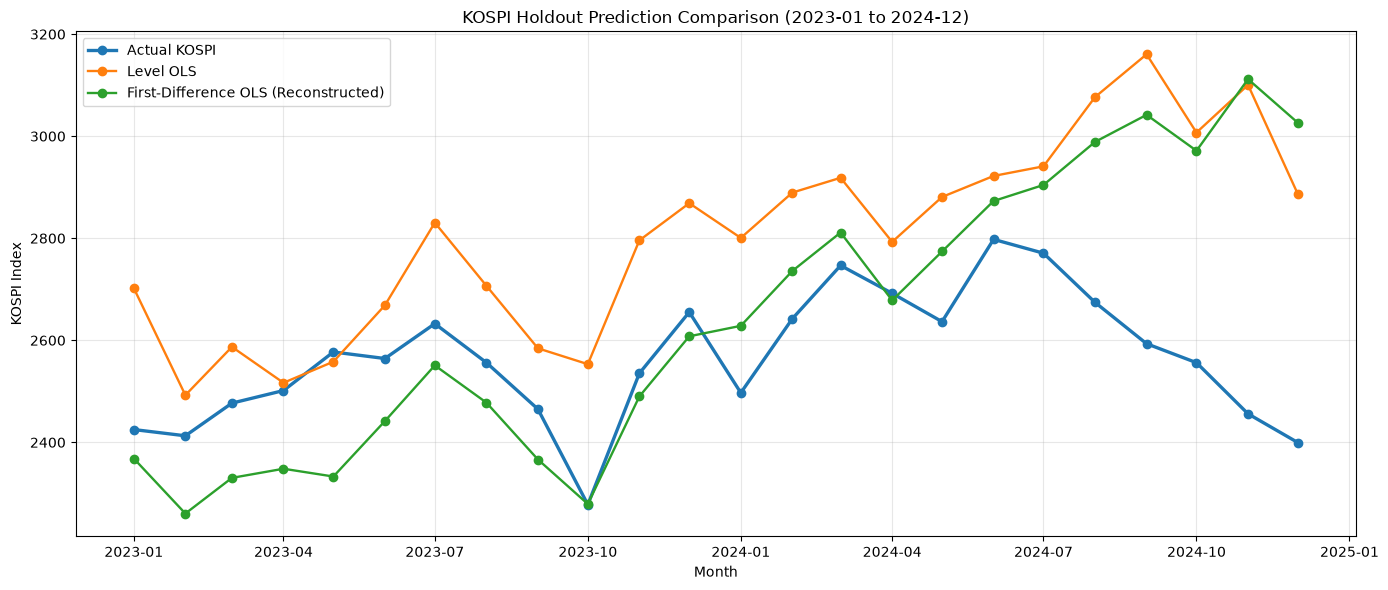

[SAVED] Same-scale holdout comparison: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\holdout_kospi_level_model_comparison.png


In [20]:
same_scale_figure_path = (
    fig_dir
    / "holdout_kospi_level_model_comparison.png"
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    level_holdout_predictions.index,
    level_holdout_predictions["actual"],
    linewidth=2.4,
    marker="o",
    label="Actual KOSPI",
)

ax.plot(
    level_holdout_predictions.index,
    level_holdout_predictions["predicted"],
    linewidth=1.7,
    marker="o",
    label="Level OLS",
)

ax.plot(
    diff_reconstructed_level_predictions.index,
    diff_reconstructed_level_predictions["predicted"],
    linewidth=1.7,
    marker="o",
    label="First-Difference OLS (Reconstructed)",
)

ax.set_title(
    "KOSPI Holdout Prediction Comparison "
    "(2023-01 to 2024-12)"
)

ax.set_xlabel("Month")
ax.set_ylabel("KOSPI Index")

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    loc="best",
)

fig.tight_layout()

fig.savefig(
    same_scale_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"[SAVED] Same-scale holdout comparison: "
    f"{same_scale_figure_path}"
)

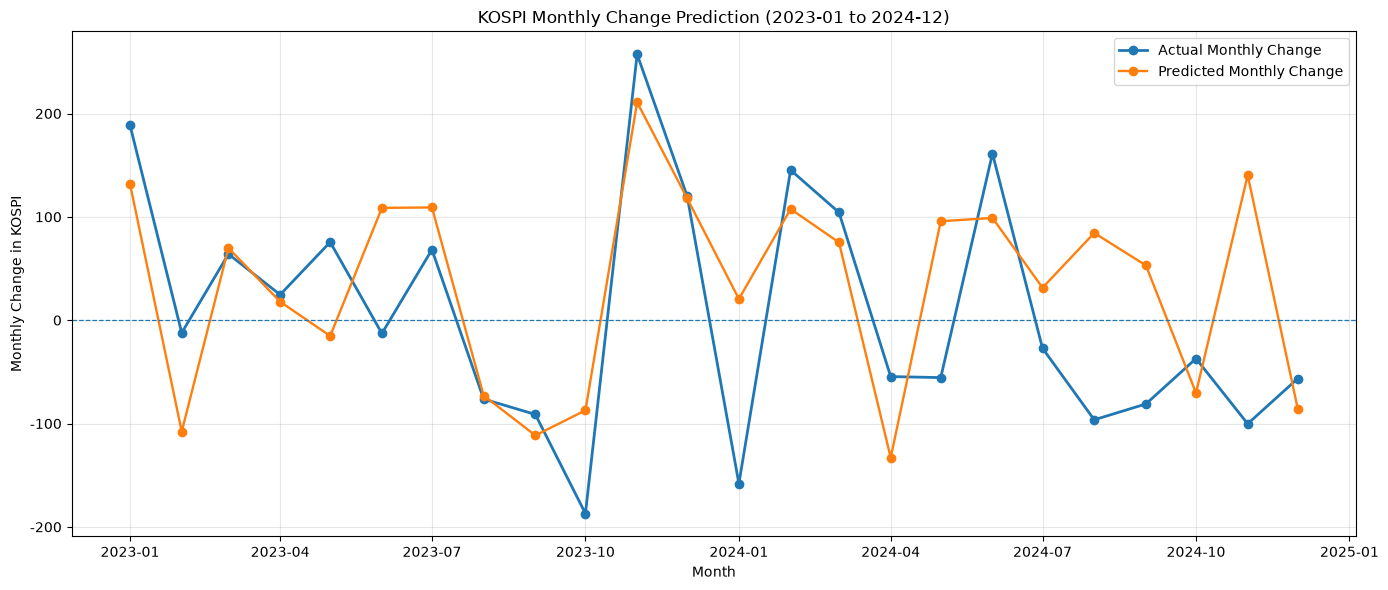

[SAVED] First-difference holdout prediction: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\holdout_kospi_first_difference_prediction.png


In [21]:
diff_prediction_figure_path = (
    fig_dir
    / "holdout_kospi_first_difference_prediction.png"
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    diff_holdout_predictions.index,
    diff_holdout_predictions["actual"],
    linewidth=2.0,
    marker="o",
    label="Actual Monthly Change",
)

ax.plot(
    diff_holdout_predictions.index,
    diff_holdout_predictions["predicted"],
    linewidth=1.7,
    marker="o",
    label="Predicted Monthly Change",
)

ax.axhline(
    y=0,
    linewidth=0.9,
    linestyle="--",
)

ax.set_title(
    "KOSPI Monthly Change Prediction "
    "(2023-01 to 2024-12)"
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly Change in KOSPI")

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    loc="best",
)

fig.tight_layout()

fig.savefig(
    diff_prediction_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"[SAVED] First-difference holdout prediction: "
    f"{diff_prediction_figure_path}"
)

## 12. 회귀 잔차 진단 시각화

통계 검정 결과를 시각적으로 보완하기 위해 각 모형의 학습 잔차를 다음 네 가지 관점에서 확인한다.

1. 시간에 따른 잔차 추이
2. 적합값과 잔차의 관계
3. 정규 Q-Q 도표
4. 잔차 자기상관함수

수준 OLS에서는 시간에 따라 같은 방향의 잔차가 지속되고 ACF가 천천히 감소하는지 확인한다.

1차 차분 OLS에서는 장기적인 자기상관이 완화되었는지 확인하되, 극단값과 두꺼운 꼬리 및 잔차 분산의 변화를 함께 검토한다.

In [22]:
def create_residual_diagnostic_figure(
    model,
    model_name: str,
    output_path: Path,
    acf_lags: int = 24,
) -> None:
    """OLS 학습 잔차의 주요 진단 그래프를 생성한다."""
    residuals = pd.Series(
        model.resid,
        copy=True,
        name="Residual",
    ).astype(float)

    fitted_values = pd.Series(
        model.fittedvalues,
        copy=True,
        name="Fitted Value",
    ).astype(float)

    if residuals.isna().any():
        raise ValueError(
            f"{model_name} 잔차에 결측치가 존재합니다."
        )

    if np.isinf(
        residuals.to_numpy(dtype=float)
    ).any():
        raise ValueError(
            f"{model_name} 잔차에 무한대 값이 존재합니다."
        )

    usable_acf_lags = min(
        acf_lags,
        len(residuals) // 3,
    )

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(15, 10),
    )

    # 1. 시간에 따른 잔차
    axes[0, 0].plot(
        residuals.index,
        residuals.values,
        linewidth=1.1,
    )

    axes[0, 0].axhline(
        y=0,
        linewidth=0.9,
        linestyle="--",
    )

    axes[0, 0].set_title(
        "Residuals over Time"
    )

    axes[0, 0].set_xlabel("Month")
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(
        True,
        alpha=0.3,
    )

    # 2. 적합값 대 잔차
    axes[0, 1].scatter(
        fitted_values,
        residuals,
        alpha=0.7,
    )

    axes[0, 1].axhline(
        y=0,
        linewidth=0.9,
        linestyle="--",
    )

    axes[0, 1].set_title(
        "Residuals vs Fitted Values"
    )

    axes[0, 1].set_xlabel("Fitted Value")
    axes[0, 1].set_ylabel("Residual")
    axes[0, 1].grid(
        True,
        alpha=0.3,
    )

    # 3. 정규 Q-Q 도표
    sm.qqplot(
        residuals,
        line="45",
        fit=True,
        ax=axes[1, 0],
    )

    axes[1, 0].set_title(
        "Normal Q-Q Plot"
    )

    axes[1, 0].grid(
        True,
        alpha=0.3,
    )

    # 4. 잔차 ACF
    sm.graphics.tsa.plot_acf(
        residuals,
        lags=usable_acf_lags,
        alpha=0.05,
        zero=False,
        ax=axes[1, 1],
    )

    axes[1, 1].set_title(
        f"Residual ACF — {usable_acf_lags} Lags"
    )

    axes[1, 1].set_xlabel("Lag (months)")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(
        True,
        alpha=0.3,
    )

    fig.suptitle(
        f"{model_name}: Residual Diagnostics",
        fontsize=15,
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

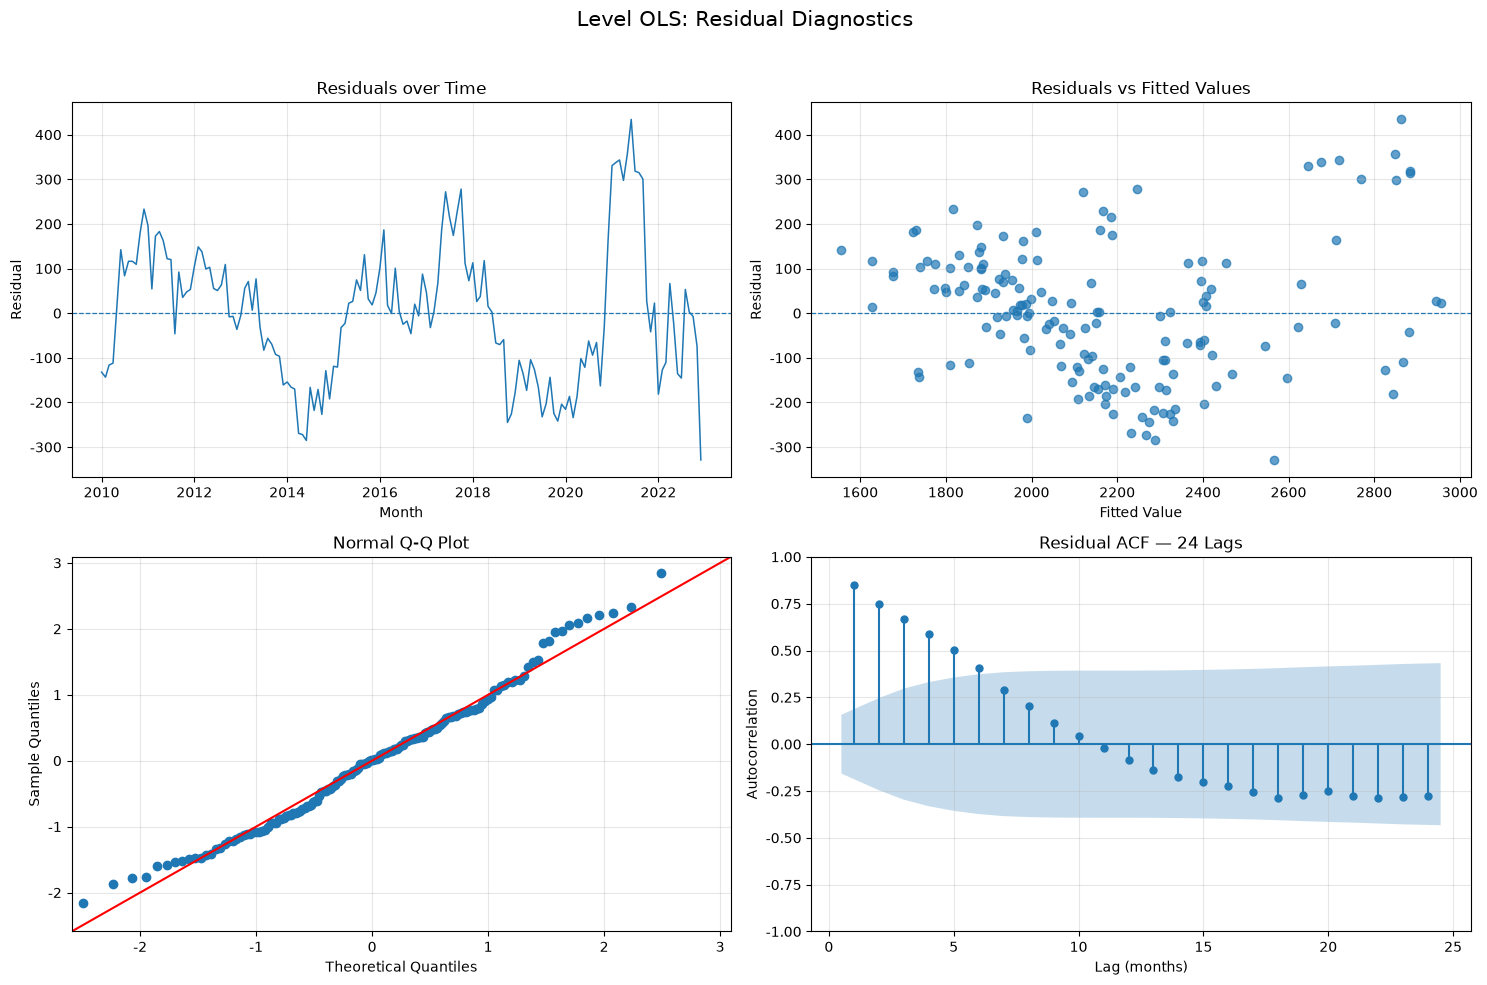

[SAVED] Level OLS residual diagnostics: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\level_ols_residual_diagnostics.png


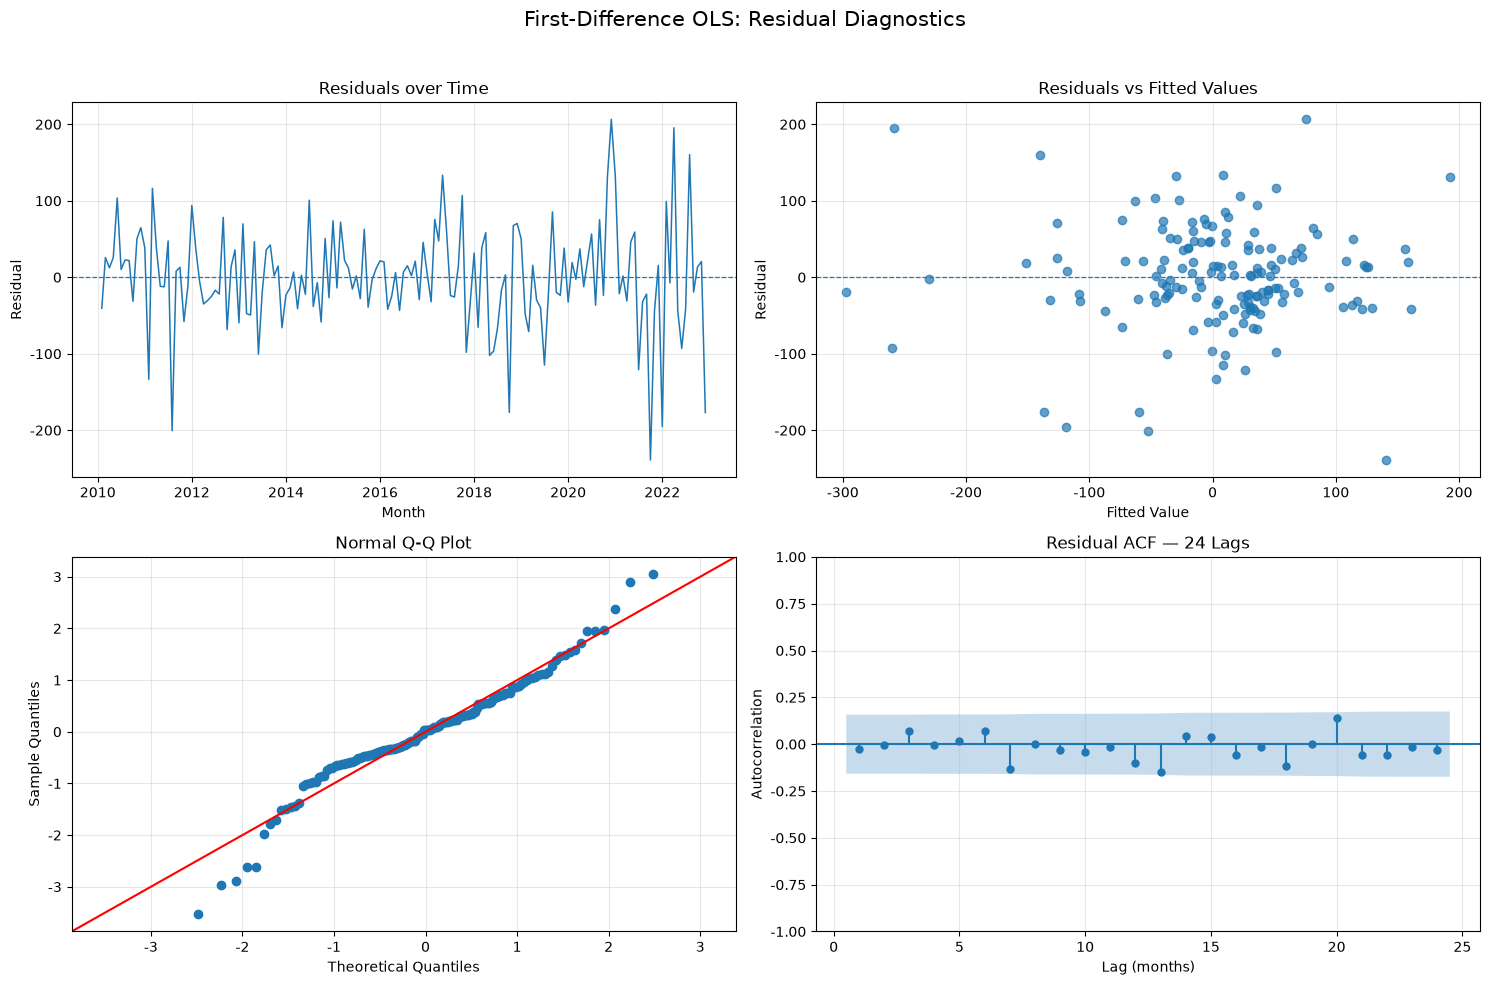

[SAVED] First-difference OLS residual diagnostics: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\diff_ols_residual_diagnostics.png


In [23]:
level_residual_figure_path = (
    fig_dir
    / "level_ols_residual_diagnostics.png"
)

diff_residual_figure_path = (
    fig_dir
    / "diff_ols_residual_diagnostics.png"
)


create_residual_diagnostic_figure(
    model=level_model,
    model_name="Level OLS",
    output_path=level_residual_figure_path,
    acf_lags=24,
)

print(
    f"[SAVED] Level OLS residual diagnostics: "
    f"{level_residual_figure_path}"
)


create_residual_diagnostic_figure(
    model=diff_model,
    model_name="First-Difference OLS",
    output_path=diff_residual_figure_path,
    acf_lags=24,
)

print(
    f"[SAVED] First-difference OLS residual diagnostics: "
    f"{diff_residual_figure_path}"
)

## 13. 표준화 잔차 기반 이상 시점 탐지

회귀모형의 잔차를 표준화하여 절댓값이 설정 기준 이상인 월을 이상 시점으로 식별한다.

표준화 잔차는 다음과 같이 계산한다.

$$
z_t
=
\frac{\varepsilon_t-\overline{\varepsilon}}
{s_{\varepsilon}}
$$

본 프로젝트에서는 `config.yaml`에 정의된 기준에 따라 다음 조건을 사용한다.

$$
|z_t| \ge 2.0
$$

이상 시점은 데이터 오류를 의미하지 않는다. 해당 시점의 KOSPI 움직임이 현재 설명변수와 선형 회귀식만으로 충분히 설명되지 않았음을 의미하며, 시장 충격이나 누락 변수 가능성을 검토하는 후보로 활용한다.

In [24]:
def extract_residual_anomalies(
    model,
    model_name: str,
    threshold: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """표준화 잔차와 임계값 이상인 관측치를 추출한다."""
    residuals = pd.Series(
        model.resid,
        copy=True,
        dtype=float,
        name="residual",
    )

    fitted_values = pd.Series(
        model.fittedvalues,
        index=residuals.index,
        dtype=float,
        name="fitted",
    )

    actual_values = pd.Series(
        np.asarray(
            model.model.endog,
            dtype=float,
        ),
        index=residuals.index,
        name="actual",
    )

    residual_mean = float(
        residuals.mean()
    )

    residual_std = float(
        residuals.std(ddof=1)
    )

    if residual_std <= 0:
        raise ValueError(
            f"{model_name} 잔차 표준편차가 0 이하입니다."
        )

    residual_zscore = (
        residuals - residual_mean
    ) / residual_std

    residual_table = pd.DataFrame(
        {
            "model": model_name,
            "actual": actual_values,
            "fitted": fitted_values,
            "residual": residuals,
            "residual_zscore": residual_zscore,
            "absolute_zscore": residual_zscore.abs(),
        }
    )

    residual_table[
        "is_anomaly"
    ] = (
        residual_table["absolute_zscore"]
        >= threshold
    )

    residual_table.index.name = "Date"

    anomaly_table = (
        residual_table.loc[
            residual_table["is_anomaly"]
        ]
        .copy()
        .sort_values(
            "absolute_zscore",
            ascending=False,
        )
    )

    return residual_table, anomaly_table

In [25]:
level_residual_table, level_residual_anomalies = (
    extract_residual_anomalies(
        model=level_model,
        model_name="Level OLS",
        threshold=RESIDUAL_Z_THRESHOLD,
    )
)

diff_residual_table, diff_residual_anomalies = (
    extract_residual_anomalies(
        model=diff_model,
        model_name="First-Difference OLS",
        threshold=RESIDUAL_Z_THRESHOLD,
    )
)


level_residual_anomaly_path = (
    metric_dir
    / "level_residual_anomalies.csv"
)

diff_residual_anomaly_path = (
    metric_dir
    / "diff_residual_anomalies.csv"
)


level_residual_anomalies.to_csv(
    level_residual_anomaly_path,
    index=True,
    index_label="Date",
    encoding="utf-8-sig",
)

diff_residual_anomalies.to_csv(
    diff_residual_anomaly_path,
    index=True,
    index_label="Date",
    encoding="utf-8-sig",
)


print(
    f"[RESIDUAL ANOMALY THRESHOLD] "
    f"|z| >= {RESIDUAL_Z_THRESHOLD:.1f}"
)

print("\n[LEVEL OLS RESIDUAL ANOMALIES]")
print(
    f"Count: {len(level_residual_anomalies)} "
    f"/ {len(level_residual_table)}"
)

display(
    level_residual_anomalies[
        [
            "actual",
            "fitted",
            "residual",
            "residual_zscore",
            "absolute_zscore",
        ]
    ].round(6)
)


print("\n[FIRST-DIFFERENCE OLS RESIDUAL ANOMALIES]")
print(
    f"Count: {len(diff_residual_anomalies)} "
    f"/ {len(diff_residual_table)}"
)

display(
    diff_residual_anomalies[
        [
            "actual",
            "fitted",
            "residual",
            "residual_zscore",
            "absolute_zscore",
        ]
    ].round(6)
)


print(
    f"\n[SAVED] Level residual anomalies: "
    f"{level_residual_anomaly_path}"
)

print(
    f"[SAVED] First-difference residual anomalies: "
    f"{diff_residual_anomaly_path}"
)

[RESIDUAL ANOMALY THRESHOLD] |z| >= 2.0

[LEVEL OLS RESIDUAL ANOMALIES]
Count: 8 / 156


,actual,fitted,residual,residual_zscore,absolute_zscore
Date,,,,,
2021-06-01,3296.679932,2862.383728,434.296204,2.833069,2.833069
2021-05-01,3203.919922,2848.120853,355.799069,2.321004,2.321004
2021-03-01,3061.419922,2718.056776,343.363146,2.239880,2.239880
2021-02-01,3012.949951,2675.205239,337.744712,2.203229,2.203229
2021-01-01,2976.209961,2645.621643,330.588318,2.156545,2.156545
2022-12-01,2236.399902,2565.351683,-328.951781,-2.145870,2.145870
2021-07-01,3202.320068,2883.993290,318.326778,2.076559,2.076559
2021-08-01,3199.270020,2884.391629,314.878390,2.054064,2.054064



[FIRST-DIFFERENCE OLS RESIDUAL ANOMALIES]
Count: 8 / 155


,actual,fitted,residual,residual_zscore,absolute_zscore
Date,,,,,
2021-10-01,-98.140137,140.744409,-238.884546,-3.524648,3.524648
2020-12-01,282.129883,75.692768,206.437114,3.045899,3.045899
2011-08-01,-253.099976,-52.513376,-200.586600,-2.959577,2.959577
2022-04-01,-62.599854,-258.076522,195.476669,2.884182,2.884182
2022-01-01,-314.309814,-119.044337,-195.265478,-2.881066,2.881066
2022-12-01,-236.130127,-59.310844,-176.819283,-2.608899,2.608899
2018-10-01,-313.380127,-136.592091,-176.788036,-2.608438,2.608438
2022-08-01,20.550049,-139.764523,160.314572,2.365379,2.365379



[SAVED] Level residual anomalies: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_residual_anomalies.csv
[SAVED] First-difference residual anomalies: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_residual_anomalies.csv


## 14. 이상 잔차의 시점별 분포

표준화 잔차를 시간 순서대로 표시하고, 절댓값이 2 이상인 이상 시점을 강조한다.

수준 OLS에서 이상 잔차가 특정 기간에 연속적으로 집중된다면 일시적인 충격보다 모형의 지속적인 과소·과대예측과 잔차 자기상관을 시사한다.

반면 1차 차분 OLS에서 이상 잔차가 여러 기간에 산발적으로 나타난다면, 장기적인 계열 상관보다는 개별 시장 충격과 두꺼운 꼬리의 영향을 받은 것으로 해석할 수 있다.

이상 시점은 데이터 오류나 특정 사건의 인과효과를 의미하지 않으며, 현재 설명변수와 선형 회귀식으로 충분히 설명되지 않은 관측치 후보이다.

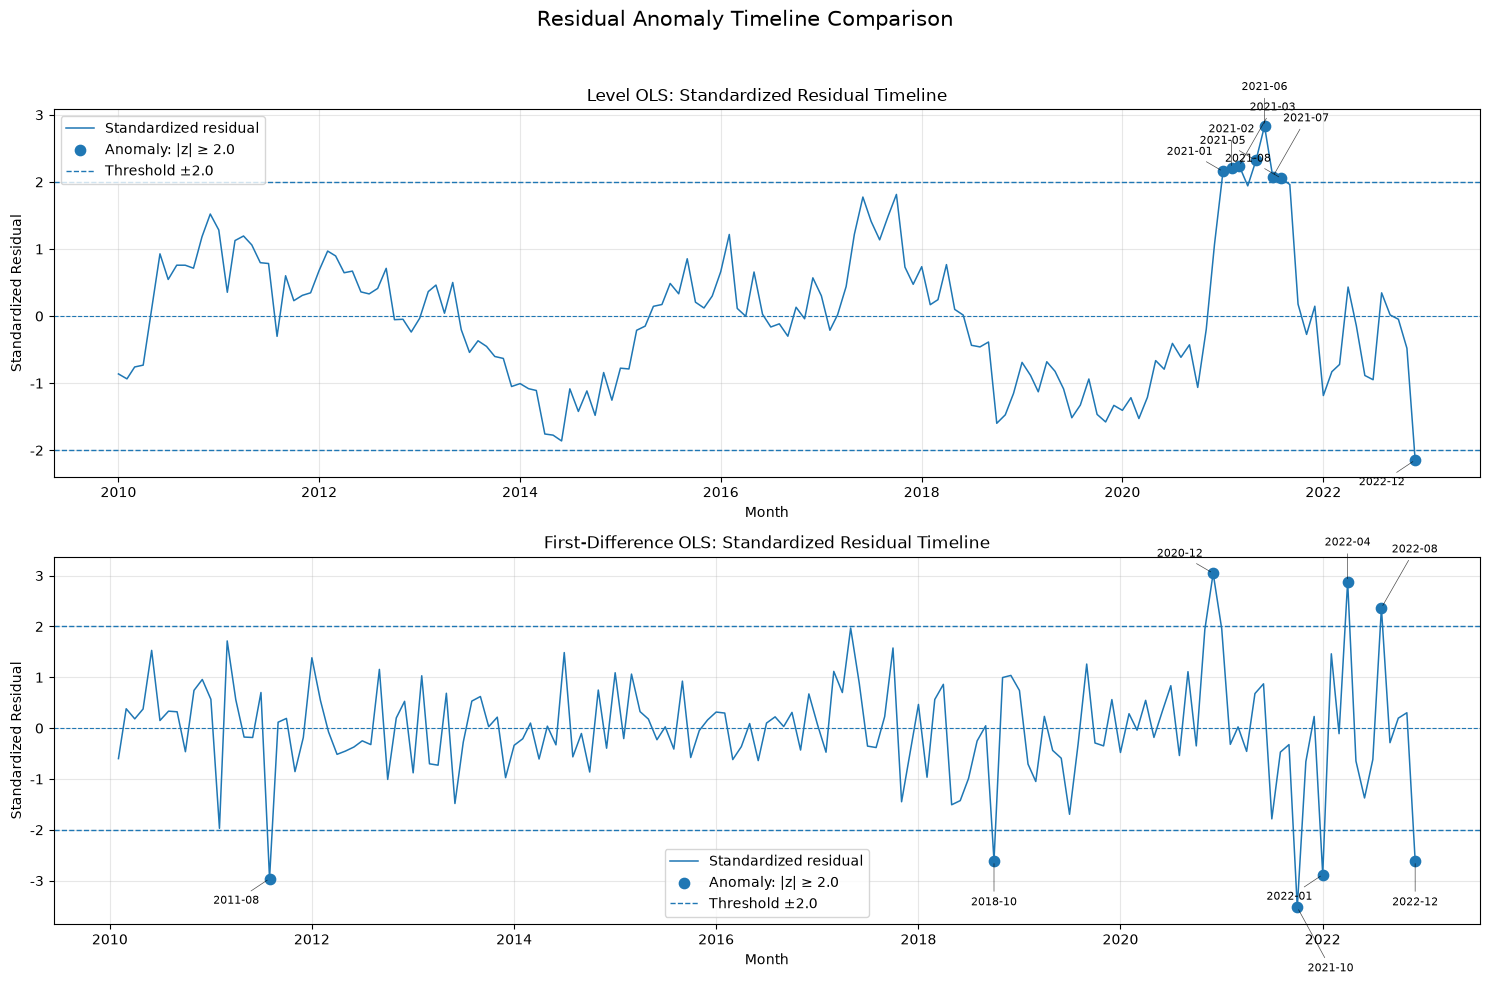

[RESIDUAL ANOMALY SUMMARY]
Level OLS: 8 / 156
Level anomaly dates: 2021-01, 2021-02, 2021-03, 2021-05, 2021-06, 2021-07, 2021-08, 2022-12

First-Difference OLS: 8 / 155
Difference anomaly dates: 2011-08, 2018-10, 2020-12, 2021-10, 2022-01, 2022-04, 2022-08, 2022-12

[SAVED] Residual anomaly timeline: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\residual_zscore_anomaly_timeline.png


In [26]:
residual_anomaly_figure_path = (
    fig_dir
    / "residual_zscore_anomaly_timeline.png"
)


def plot_residual_anomaly_timeline(
    level_table: pd.DataFrame,
    diff_table: pd.DataFrame,
    threshold: float,
    output_path: Path,
) -> None:
    """수준·차분 모형의 표준화 잔차와 이상 시점을 비교한다."""
    plot_data = [
        (
            level_table,
            "Level OLS",
        ),
        (
            diff_table,
            "First-Difference OLS",
        ),
    ]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(15, 10),
    )

    for ax, (table, model_name) in zip(
        axes,
        plot_data,
    ):
        ordered_table = (
            table
            .sort_index()
            .copy()
        )

        anomaly_table = ordered_table.loc[
            ordered_table["is_anomaly"]
        ]

        ax.plot(
            ordered_table.index,
            ordered_table["residual_zscore"],
            linewidth=1.1,
            label="Standardized residual",
        )

        ax.scatter(
            anomaly_table.index,
            anomaly_table["residual_zscore"],
            s=55,
            marker="o",
            label=f"Anomaly: |z| ≥ {threshold:.1f}",
            zorder=3,
        )

        ax.axhline(
            y=0,
            linewidth=0.8,
            linestyle="--",
        )

        ax.axhline(
            y=threshold,
            linewidth=1.0,
            linestyle="--",
            label=f"Threshold ±{threshold:.1f}",
        )

        ax.axhline(
            y=-threshold,
            linewidth=1.0,
            linestyle="--",
        )

        positive_label_count = 0
        negative_label_count = 0

        for date, row in anomaly_table.iterrows():
            z_value = float(
                row["residual_zscore"]
            )

            if z_value >= 0:
                label_position = positive_label_count

                x_offsets = [
                    -24,
                    0,
                    24,
                ]

                y_offsets = [
                    10,
                    24,
                    38,
                ]

                x_offset = x_offsets[
                    label_position % len(x_offsets)
                ]

                y_offset = y_offsets[
                    label_position % len(y_offsets)
                ]

                vertical_alignment = "bottom"
                positive_label_count += 1

            else:
                label_position = negative_label_count

                x_offsets = [
                    -24,
                    0,
                    24,
                ]

                y_offsets = [
                    -12,
                    -26,
                    -40,
                ]

                x_offset = x_offsets[
                    label_position % len(x_offsets)
                ]

                y_offset = y_offsets[
                    label_position % len(y_offsets)
                ]

                vertical_alignment = "top"
                negative_label_count += 1

            ax.annotate(
                date.strftime("%Y-%m"),
                xy=(
                    date,
                    z_value,
                ),
                xytext=(
                    x_offset,
                    y_offset,
                ),
                textcoords="offset points",
                ha="center",
                va=vertical_alignment,
                fontsize=8,
                arrowprops={
                    "arrowstyle": "-",
                    "linewidth": 0.5,
                    "alpha": 0.7,
                },
            )

        ax.set_title(
            f"{model_name}: Standardized Residual Timeline"
        )

        ax.set_xlabel("Month")
        ax.set_ylabel("Standardized Residual")

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            loc="best",
        )

    fig.suptitle(
        "Residual Anomaly Timeline Comparison",
        fontsize=15,
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


plot_residual_anomaly_timeline(
    level_table=level_residual_table,
    diff_table=diff_residual_table,
    threshold=RESIDUAL_Z_THRESHOLD,
    output_path=residual_anomaly_figure_path,
)


print("[RESIDUAL ANOMALY SUMMARY]")

print(
    f"Level OLS: "
    f"{len(level_residual_anomalies)} "
    f"/ {len(level_residual_table)}"
)

print(
    "Level anomaly dates: "
    + ", ".join(
        level_residual_anomalies
        .sort_index()
        .index
        .strftime("%Y-%m")
        .tolist()
    )
)

print(
    f"\nFirst-Difference OLS: "
    f"{len(diff_residual_anomalies)} "
    f"/ {len(diff_residual_table)}"
)

print(
    "Difference anomaly dates: "
    + ", ".join(
        diff_residual_anomalies
        .sort_index()
        .index
        .strftime("%Y-%m")
        .tolist()
    )
)

print(
    f"\n[SAVED] Residual anomaly timeline: "
    f"{residual_anomaly_figure_path}"
)

## 15. 핵심 회귀 결과 저장

수준 OLS와 1차 차분 OLS의 적합 결과, 회귀계수 및 HAC 강건 추론 결과를 재사용 가능한 형태로 저장한다.

일반 OLS 결과와 HAC 결과를 모두 보존하되, 최종적인 차분 모형의 계수 유의성 해석에는 이분산성에 강건한 HAC 결과를 우선 사용한다.

수준 모형의 결과는 비정상성, 공적분 부재 및 강한 잔차 자기상관을 고려하여 비교·진단 목적으로만 보존한다.

In [27]:
model_fit_summary_path = (
    metric_dir / "model_fit_summary.csv"
)

level_coefficient_path = (
    metric_dir / "level_ols_coefficients.csv"
)

diff_coefficient_path = (
    metric_dir / "diff_ols_coefficients.csv"
)

model_diagnostics_comparison_path = (
    metric_dir / "model_diagnostics_comparison.csv"
)


model_fit_summary.to_csv(
    model_fit_summary_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)

level_coefficient_table.to_csv(
    level_coefficient_path,
    index=True,
    index_label="term",
    encoding="utf-8-sig",
)

diff_coefficient_table.to_csv(
    diff_coefficient_path,
    index=True,
    index_label="term",
    encoding="utf-8-sig",
)


diagnostic_comparison = (
    model_fit_summary
    .join(
        residual_diagnostics[
            [
                "durbin_watson",
                "ljung_box_pvalue",
                "autocorrelation_detected",
                "breusch_pagan_lm_pvalue",
                "heteroskedasticity_detected",
                "jarque_bera_pvalue",
                "normality_rejected",
            ]
        ],
        how="left",
    )
)

diagnostic_comparison[
    "maximum_vif"
] = [
    float(level_vif["vif"].max()),
    float(diff_vif["vif"].max()),
]

diagnostic_comparison[
    "residual_anomaly_count"
] = [
    len(level_residual_anomalies),
    len(diff_residual_anomalies),
]

diagnostic_comparison.to_csv(
    model_diagnostics_comparison_path,
    index=True,
    index_label="model",
    encoding="utf-8-sig",
)


print("[MODEL DIAGNOSTICS COMPARISON]")

display(
    diagnostic_comparison.round(6)
)

print(
    f"\n[SAVED] Model fit summary: "
    f"{model_fit_summary_path}"
)

print(
    f"[SAVED] Level OLS coefficients: "
    f"{level_coefficient_path}"
)

print(
    f"[SAVED] First-difference OLS coefficients: "
    f"{diff_coefficient_path}"
)

print(
    f"[SAVED] Model diagnostics comparison: "
    f"{model_diagnostics_comparison_path}"
)

[MODEL DIAGNOSTICS COMPARISON]


,n_observations,r_squared,adjusted_r_squared,f_statistic,f_pvalue,aic,bic,condition_number,durbin_watson,ljung_box_pvalue,autocorrelation_detected,breusch_pagan_lm_pvalue,heteroskedasticity_detected,jarque_bera_pvalue,normality_rejected,maximum_vif,residual_anomaly_count
model,,,,,,,,,,,,,,,,,
Level OLS,156,0.810265,0.805239,161.211666,0.0,2021.803884,2037.053164,61544.39085,0.261111,0.000000,True,0.000001,True,0.195416,False,5.783620,8
First-Difference OLS,155,0.561996,0.550316,48.115648,0.0,1755.889635,1771.106761,889.25316,2.010219,0.859924,False,0.009529,True,0.000006,True,1.325317,8



[SAVED] Model fit summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\model_fit_summary.csv
[SAVED] Level OLS coefficients: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\level_ols_coefficients.csv
[SAVED] First-difference OLS coefficients: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\diff_ols_coefficients.csv
[SAVED] Model diagnostics comparison: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\model_diagnostics_comparison.csv


In [30]:
report_dir.mkdir(
    parents=True,
    exist_ok=True,
)


level_ols_summary_path = (
    report_dir
    / "level_ols_summary.txt"
)

diff_ols_summary_path = (
    report_dir
    / "diff_ols_summary.txt"
)

level_hac_summary_path = (
    report_dir
    / "level_ols_hac_summary.txt"
)

diff_hac_summary_path = (
    report_dir
    / "diff_ols_hac_summary.txt"
)


def normalize_text_output(
    text: str,
) -> str:
    """
    각 줄 끝의 불필요한 공백을 제거하고
    파일 마지막 개행을 하나만 유지한다.
    """
    cleaned_lines = [
        line.rstrip()
        for line in text.splitlines()
    ]

    cleaned_text = "\n".join(
        cleaned_lines
    ).rstrip()

    return cleaned_text + "\n"


summary_outputs = {
    level_ols_summary_path: (
        level_model
        .summary()
        .as_text()
    ),
    diff_ols_summary_path: (
        diff_model
        .summary()
        .as_text()
    ),
    level_hac_summary_path: (
        level_hac_result
        .summary()
        .as_text()
    ),
    diff_hac_summary_path: (
        diff_hac_result
        .summary()
        .as_text()
    ),
}


for output_path, summary_text in summary_outputs.items():
    output_path.write_text(
        normalize_text_output(
            summary_text
        ),
        encoding="utf-8",
    )


print(
    f"[SAVED] Level OLS summary: "
    f"{level_ols_summary_path}"
)

print(
    f"[SAVED] First-difference OLS summary: "
    f"{diff_ols_summary_path}"
)

print(
    f"[SAVED] Level OLS HAC summary: "
    f"{level_hac_summary_path}"
)

print(
    f"[SAVED] First-difference OLS HAC summary: "
    f"{diff_hac_summary_path}"
)

[SAVED] Level OLS summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\reports\level_ols_summary.txt
[SAVED] First-difference OLS summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\reports\diff_ols_summary.txt
[SAVED] Level OLS HAC summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\reports\level_ols_hac_summary.txt
[SAVED] First-difference OLS HAC summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\reports\diff_ols_hac_summary.txt


## 16. 모델링 결과 종합 결론

수준 OLS는 학습 구간에서 높은 결정계수를 보였지만, 수준 변수의 비정상성, 공적분 부재, 강한 잔차 자기상관 및 이분산성이 함께 확인되었다. 따라서 수준 모형의 높은 설명력과 유의한 회귀계수를 장기 경제관계나 인과관계로 해석하지 않는다.

1차 차분 OLS는 모든 변수의 정상성이 확보된 월간 변화량을 사용하였다. 잔차 자기상관은 발견되지 않았지만 이분산성과 비정규성이 확인되어, 최종 계수 추론에는 HAC(Newey–West) 강건 표준오차를 적용하였다.

HAC 기준으로 원/달러 환율 변화는 KOSPI 변화와 유의한 음의 관계, S&P 500 변화와 WTI 변화는 유의한 양의 관계를 보였다. 금리 변화는 일반 OLS에서는 5% 수준에서 유의했으나 HAC 적용 후에는 유의하지 않았다.

홀드아웃 기간의 월간 KOSPI 변화량 예측에서는 일정한 설명력과 방향 정확도가 확인되었지만, 예측 변화량을 누적한 KOSPI 수준 경로는 단순 평균 기준보다 낮은 결정계수를 보였다. 따라서 본 프로젝트의 핵심 성과는 높은 주가지수 예측 성능이 아니라, 비정상 금융 시계열의 허위회귀 위험을 진단하고 통계적으로 타당한 변환과 추론 절차를 구축한 데 있다.


In [29]:
def format_pvalue(value: float) -> str:
    """작은 p-value를 0으로 오해하지 않도록 표시한다."""
    if value < 0.000001:
        return "< 0.000001"

    return f"{value:.6f}"


level_diag = residual_diagnostics.loc[
    "Level OLS"
]

diff_diag = residual_diagnostics.loc[
    "First-Difference OLS"
]

cointegration_row = (
    cointegration_result.iloc[0]
)

level_holdout_row = (
    level_holdout_metrics.iloc[0]
)

diff_holdout_row = (
    diff_holdout_metrics.iloc[0]
)

reconstructed_row = (
    diff_reconstructed_level_metrics.iloc[0]
)


hac_result_rows = []

for term, row in diff_hac_comparison.iterrows():
    if term == "const":
        interpretation = (
            "월간 평균 변화 절편"
        )

    elif term == "Exchange_Rate":
        interpretation = (
            "환율 상승과 KOSPI 변화 사이의 음의 관계"
        )

    elif term == "Interest_Rate":
        interpretation = (
            "5% 유의수준에서 명확하지 않은 음의 관계"
        )

    elif term == "SP500":
        interpretation = (
            "S&P 500 상승과 KOSPI 변화 사이의 양의 관계"
        )

    elif term == "WTI_Oil":
        interpretation = (
            "WTI 상승과 KOSPI 변화 사이의 양의 관계"
        )

    else:
        interpretation = ""

    hac_result_rows.append(
        "| "
        f"{term} | "
        f"{row['coefficient']:.6f} | "
        f"{row['hac_standard_error']:.6f} | "
        f"{format_pvalue(row['hac_p_value'])} | "
        f"{row['hac_ci_lower_95']:.6f} | "
        f"{row['hac_ci_upper_95']:.6f} | "
        f"{'유의' if row['hac_significant_5pct'] else '유의하지 않음'} | "
        f"{interpretation} |"
    )


level_mae_improvement = (
    (
        level_holdout_row["mae"]
        - reconstructed_row["mae"]
    )
    / level_holdout_row["mae"]
    * 100
)

level_rmse_improvement = (
    (
        level_holdout_row["rmse"]
        - reconstructed_row["rmse"]
    )
    / level_holdout_row["rmse"]
    * 100
)


modeling_report_lines = [
    "# KOSPI 거시경제 회귀모형 분석 결과",
    "",
    f"- 실행 시각: {RUN_TIMESTAMP:%Y-%m-%d %H:%M:%S} KST",
    "- 학습 기간: 2010-01 ~ 2022-12",
    "- 홀드아웃 기간: 2023-01 ~ 2024-12",
    f"- 종속변수: {MODEL_TARGET}",
    f"- 설명변수: {', '.join(MODEL_FEATURES)}",
    "",
    "## 1. 분석 설계",
    "",
    (
        "- 수준 OLS는 비정상 시계열 회귀에서 발생할 수 있는 "
        "허위회귀 위험을 확인하는 비교 모형으로 사용하였다."
    ),
    (
        "- 1차 차분 OLS는 정상성이 확인된 월간 변화량을 "
        "사용한 주 분석 모형이다."
    ),
    (
        "- 시계열 순서를 유지하여 가장 최근 24개월을 "
        "홀드아웃 구간으로 분리하였다."
    ),
    (
        "- 차분 모형의 최종 통계적 추론에는 최대 시차 "
        f"{HAC_MAXLAGS}개월의 HAC(Newey–West) "
        "강건 표준오차를 사용하였다."
    ),
    "",
    "## 2. 수준 OLS 진단",
    "",
    f"- 학습 R²: {level_model.rsquared:.6f}",
    (
        f"- Durbin–Watson 통계량: "
        f"{level_diag['durbin_watson']:.6f}"
    ),
    (
        f"- Ljung–Box p-value: "
        f"{format_pvalue(level_diag['ljung_box_pvalue'])}"
    ),
    (
        f"- Breusch–Pagan p-value: "
        f"{format_pvalue(level_diag['breusch_pagan_lm_pvalue'])}"
    ),
    (
        f"- Engle–Granger 공적분 검정 p-value: "
        f"{cointegration_row['p_value']:.6f}"
    ),
    (
        "- 수준 변수는 정상성이 확보되지 않았으며, "
        "공적분이 없다는 귀무가설도 기각하지 못하였다."
    ),
    (
        "- 잔차에는 강한 양의 자기상관과 이분산성이 존재한다."
    ),
    (
        "- 따라서 수준 OLS의 높은 R²와 유의한 계수는 "
        "장기 균형관계의 근거로 사용하지 않는다."
    ),
    "",
    "## 3. 1차 차분 OLS 진단",
    "",
    f"- 학습 R²: {diff_model.rsquared:.6f}",
    (
        f"- Durbin–Watson 통계량: "
        f"{diff_diag['durbin_watson']:.6f}"
    ),
    (
        f"- Ljung–Box p-value: "
        f"{diff_diag['ljung_box_pvalue']:.6f}"
    ),
    (
        f"- Breusch–Pagan p-value: "
        f"{diff_diag['breusch_pagan_lm_pvalue']:.6f}"
    ),
    (
        f"- Jarque–Bera p-value: "
        f"{format_pvalue(diff_diag['jarque_bera_pvalue'])}"
    ),
    (
        "- 차분 후 잔차 자기상관은 발견되지 않았지만, "
        "이분산성과 비정규성이 확인되었다."
    ),
    (
        "- 이에 따라 일반 OLS 표준오차 대신 HAC 결과를 "
        "최종 계수 해석에 사용하였다."
    ),
    "",
    "## 4. 차분 모형 HAC 계수 결과",
    "",
    (
        "| 항 | 계수 | HAC 표준오차 | HAC p-value | "
        "95% 하한 | 95% 상한 | 5% 판단 | 해석 |"
    ),
    (
        "|---|---:|---:|---:|---:|---:|---|---|"
    ),
    *hac_result_rows,
    "",
    "## 5. 홀드아웃 성능",
    "",
    "### 월간 KOSPI 변화량",
    "",
    f"- MAE: {diff_holdout_row['mae']:.6f}",
    f"- RMSE: {diff_holdout_row['rmse']:.6f}",
    f"- R²: {diff_holdout_row['r_squared']:.6f}",
    (
        f"- 방향 정확도: "
        f"{diff_holdout_row['directional_accuracy']:.2%}"
    ),
    "",
    "### KOSPI 수준 척도 비교",
    "",
    (
        "| 모형 | MAE | RMSE | R² | 평균오차 |"
    ),
    (
        "|---|---:|---:|---:|---:|"
    ),
    (
        "| 수준 OLS | "
        f"{level_holdout_row['mae']:.6f} | "
        f"{level_holdout_row['rmse']:.6f} | "
        f"{level_holdout_row['r_squared']:.6f} | "
        f"{level_holdout_row['mean_error']:.6f} |"
    ),
    (
        "| 차분 OLS 수준 복원 | "
        f"{reconstructed_row['mae']:.6f} | "
        f"{reconstructed_row['rmse']:.6f} | "
        f"{reconstructed_row['r_squared']:.6f} | "
        f"{reconstructed_row['mean_error']:.6f} |"
    ),
    "",
    (
        f"- 차분 복원 모형의 MAE는 수준 OLS보다 "
        f"{level_mae_improvement:.2f}% 감소하였다."
    ),
    (
        f"- 차분 복원 모형의 RMSE는 수준 OLS보다 "
        f"{level_rmse_improvement:.2f}% 감소하였다."
    ),
    (
        "- 그러나 두 수준 예측 모형 모두 홀드아웃 R²가 "
        "0보다 작아 평균 기준보다 낮은 수준 경로 예측력을 보였다."
    ),
    "",
    "## 6. 이상 잔차",
    "",
    (
        f"- 수준 OLS 이상 잔차: "
        f"{len(level_residual_anomalies)}/"
        f"{len(level_residual_table)}개"
    ),
    (
        "- 수준 모형의 이상 잔차는 주로 2021년에 연속적으로 "
        "집중되어 구조적 미적합과 자기상관을 시사한다."
    ),
    (
        f"- 차분 OLS 이상 잔차: "
        f"{len(diff_residual_anomalies)}/"
        f"{len(diff_residual_table)}개"
    ),
    (
        "- 차분 모형의 이상 잔차는 여러 시점에 산발적으로 "
        "나타나며 급격한 시장 변동과 두꺼운 꼬리 가능성을 보여준다."
    ),
    "",
    "## 7. 최종 결론",
    "",
    (
        "- 수준 OLS는 허위회귀 위험을 보여주는 비교·진단 "
        "모형으로만 사용한다."
    ),
    (
        "- 1차 차분 OLS는 월간 변화량 사이의 단기 연관성을 "
        "분석하는 주 모형이다."
    ),
    (
        "- HAC 기준으로 환율 변화는 음의 관계, S&P 500 및 "
        "WTI 변화는 양의 관계가 통계적으로 유의하였다."
    ),
    (
        "- 금리 변화는 HAC 적용 후 5% 유의수준에서 "
        "유의하지 않았다."
    ),
    (
        "- 분석 결과는 인과효과가 아니라 동시점의 통계적 "
        "연관성으로 해석한다."
    ),
    (
        "- 본 프로젝트의 핵심 성과는 높은 예측 정확도보다 "
        "정상성 진단, 공적분 검정, 잔차 진단 및 강건 추론을 "
        "통한 분석 타당성 확보에 있다."
    ),
]


modeling_findings_path = (
    report_dir / "modeling_findings.md"
)

modeling_findings_path.write_text(
    "\n".join(modeling_report_lines),
    encoding="utf-8",
)


print(
    f"[SAVED] Modeling findings report: "
    f"{modeling_findings_path}"
)

print("\n[REPORT PREVIEW]\n")

print(
    "\n".join(
        modeling_report_lines[:45]
    )
)

[SAVED] Modeling findings report: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\reports\modeling_findings.md

[REPORT PREVIEW]

# KOSPI 거시경제 회귀모형 분석 결과

- 실행 시각: 2026-06-27 07:41:19 KST
- 학습 기간: 2010-01 ~ 2022-12
- 홀드아웃 기간: 2023-01 ~ 2024-12
- 종속변수: KOSPI
- 설명변수: Exchange_Rate, Interest_Rate, SP500, WTI_Oil

## 1. 분석 설계

- 수준 OLS는 비정상 시계열 회귀에서 발생할 수 있는 허위회귀 위험을 확인하는 비교 모형으로 사용하였다.
- 1차 차분 OLS는 정상성이 확인된 월간 변화량을 사용한 주 분석 모형이다.
- 시계열 순서를 유지하여 가장 최근 24개월을 홀드아웃 구간으로 분리하였다.
- 차분 모형의 최종 통계적 추론에는 최대 시차 12개월의 HAC(Newey–West) 강건 표준오차를 사용하였다.

## 2. 수준 OLS 진단

- 학습 R²: 0.810265
- Durbin–Watson 통계량: 0.261111
- Ljung–Box p-value: < 0.000001
- Breusch–Pagan p-value: 0.000001
- Engle–Granger 공적분 검정 p-value: 0.590111
- 수준 변수는 정상성이 확보되지 않았으며, 공적분이 없다는 귀무가설도 기각하지 못하였다.
- 잔차에는 강한 양의 자기상관과 이분산성이 존재한다.
- 따라서 수준 OLS의 높은 R²와 유의한 계수는 장기 균형관계의 근거로 사용하지 않는다.

## 3. 1차 차분 OLS 진단

- 학습 R²: 0.561996
- Durbin–Watson 통계량: 2.010219
- Ljung–Box p-value: 0.859924
- Breusch–Pagan p-value: 0.009529
- Jarque–Bera 